# Comparison of Two Conditional DCGANs on Fashion MNIST

The goal of the project is not only to train two models from the DCGAN family, but also to test how reliably they generate clothing images for a requested class.

The experiment compares two generator architectures while keeping the discriminator, data, training loop, and metric set identical:

1. **Baseline conditional DCGAN** - a compact generator with transposed convolutions. It is closer to the classical DCGAN idea and serves as a strong baseline model.
2. **Enhanced conditional DCGAN** - a deeper generator with image upsampling and convolutional refinement. It tests the hypothesis that a more complex generator can produce smoother and more stable images.

The key research question is: **does increasing generator complexity improve Fashion MNIST generation quality, or is a compact DCGAN sufficient for 28 x 28 images?**

A unified training scheme is used for a fair comparison:

- the same conditional projection discriminator;
- a hinge loss for the GAN;
- an EMA version of the generator for final evaluation;
- identical optimization parameters;
- identical quality-evaluation samples;
- an independent evaluation classifier that does not participate in GAN training.

Quality is assessed from several perspectives. A single metric is insufficient for GANs, so the study uses an FID-like score, class coverage, requested-label match, feature diversity, sharp pixel-transition indicators, visual grids, and a nearest-neighbor check.


## 1. Library Imports


In [1]:
# Core Python libraries.
import json
import math
import os
import random
import subprocess
import time
import warnings
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

# Numerical computation and tables.
import numpy as np
import pandas as pd

# Visualization.
import matplotlib.pyplot as plt

# Table display in the notebook.
from IPython.display import display

# TensorFlow and Keras.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# sqrtm is required for the FID-like score.
from scipy import linalg

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 2. Project Configuration

This block defines a single configuration for the experiment. All key parameters are collected in `ExperimentConfig`: image size, number of classes, latent-vector size, classifier parameters, GAN parameters, evaluation frequency, EMA settings, and early-stopping limits.

Profiles for different compute devices are defined separately. This approach allows the same notebook to run on T4, L4, and A100 without manually rewriting the code. The profile selects the batch size, the number of steps per epoch, and the mixed-precision mode.

The research motivation for this design is controllability. If a parameter affects speed, stability, or quality, it should be located in the configuration rather than hidden in the middle of a function.


In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    """Stores the parameters of the complete experiment."""

    # General parameters.
    seed: int = 42
    num_classes: int = 10
    image_size: int = 28
    channels: int = 1
    latent_dim: int = 128

    # Parameters of the classifier used only for quality evaluation.
    classifier_epochs: int = 25
    classifier_batch_size: int = 512
    classifier_learning_rate: float = 1e-3

    # GAN training parameters.
    gan_epochs: int = 180
    steps_per_epoch: int = 220
    batch_size: int = 512
    generator_learning_rate: float = 2e-4
    discriminator_learning_rate: float = 2e-4
    adam_beta_1: float = 0.0
    adam_beta_2: float = 0.9
    global_clipnorm: float = 5.0

    # Conditional training.
    wrong_label_weight: float = 0.25
    generator_total_variation_weight: float = 0.02

    # Generator-weight smoothing for final generation.
    ema_decay: float = 0.999

    # Light noise and augmentation for discriminator inputs.
    instance_noise_initial: float = 0.08
    instance_noise_decay_epochs: int = 80
    augmentation_probability: float = 0.35
    max_translation: int = 2

    # Quality-evaluation frequency.
    evaluation_every: int = 5
    eval_samples: int = 3000
    final_eval_samples: int = 6000
    grid_samples_per_class: int = 10

    # Callbacks for the custom training loop.
    plateau_patience: int = 5
    early_stop_patience: int = 18
    lr_reduce_factor: float = 0.65
    min_learning_rate: float = 3e-6
    quality_min_delta: float = 0.002

    # Performance.
    mixed_precision: bool = True


@dataclass(frozen=True)
class HardwareProfile:
    """Describes settings for a specific GPU."""

    batch_size: int
    steps_per_epoch: int
    gan_epochs: int
    eval_samples: int
    final_eval_samples: int
    mixed_precision: bool


HARDWARE_PROFILES: Dict[str, HardwareProfile] = {
    "T4": HardwareProfile(
        batch_size=384,
        steps_per_epoch=200,
        gan_epochs=180,
        eval_samples=2500,
        final_eval_samples=5000,
        mixed_precision=True,
    ),
    "L4": HardwareProfile(
        batch_size=512,
        steps_per_epoch=220,
        gan_epochs=180,
        eval_samples=3000,
        final_eval_samples=6000,
        mixed_precision=True,
    ),
    "A100": HardwareProfile(
        batch_size=768,
        steps_per_epoch=260,
        gan_epochs=200,
        eval_samples=5000,
        final_eval_samples=10000,
        mixed_precision=True,
    ),
    "CPU": HardwareProfile(
        batch_size=128,
        steps_per_epoch=40,
        gan_epochs=20,
        eval_samples=1000,
        final_eval_samples=2000,
        mixed_precision=False,
    ),
}

PROJECT_DIR = Path("/content/dcgan_fashion_mnist_final") if Path("/content").exists() else Path("dcgan_fashion_mnist_final")
IMAGE_DIR = PROJECT_DIR / "images"
MODEL_DIR = PROJECT_DIR / "models"
TABLE_DIR = PROJECT_DIR / "tables"

for directory in [PROJECT_DIR, IMAGE_DIR, MODEL_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


After execution, the base configuration, a dictionary of hardware profiles, and artifact directories are created. An important research advantage is that all training parameters are defined centrally.

In this version, the main GAN parameters are not scattered throughout the code. This reduces the risk of accidental differences between the two models and makes the experiment reproducible.


## 3. Hardware Profile Detection

This block detects the available GPU through `nvidia-smi`, selects a training profile, and prints the resulting configuration. This is especially important in Colab because T4, L4, and A100 have different amounts of video memory and different performance characteristics.

The study uses fixed profile-selection logic. If an L4 is detected, the profile with a larger batch size and a higher number of steps per epoch is selected. If no GPU is detected, a minimal CPU profile is selected only to verify code correctness.

The result of this block determines the compute mode for the entire experiment: training speed, memory consumption, number of weight updates, and stability of GPU utilization.


In [3]:
def query_gpu_name() -> str:
    """Returns the name of the first available GPU through nvidia-smi."""
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            check=True,
            capture_output=True,
            text=True,
        )
        names = [line.strip() for line in result.stdout.splitlines() if line.strip()]
        return names[0] if names else "CPU"
    except Exception:
        return "CPU"


def select_profile_name(gpu_name: str) -> str:
    """Selects a profile name from the GPU name."""
    normalized_name = gpu_name.upper()
    lookup = {
        "A100": "A100",
        "L4": "L4",
        "T4": "T4",
    }
    for marker, profile_name in lookup.items():
        if marker in normalized_name:
            return profile_name
    return "CPU" if not tf.config.list_physical_devices("GPU") else "L4"


def make_config_for_hardware() -> Tuple[ExperimentConfig, str, str]:
    """Creates the final configuration for the current GPU."""
    gpu_name = query_gpu_name()
    profile_name = select_profile_name(gpu_name)
    profile = HARDWARE_PROFILES[profile_name]

    base_config = ExperimentConfig()
    config = replace(
        base_config,
        batch_size=profile.batch_size,
        steps_per_epoch=profile.steps_per_epoch,
        gan_epochs=profile.gan_epochs,
        eval_samples=profile.eval_samples,
        final_eval_samples=profile.final_eval_samples,
        mixed_precision=profile.mixed_precision,
    )
    return config, gpu_name, profile_name


CONFIG, GPU_NAME, PROFILE_NAME = make_config_for_hardware()

print(f"GPU: {GPU_NAME}")
print(f"Selected profile: {PROFILE_NAME}")
print(json.dumps(asdict(CONFIG), ensure_ascii=False, indent=2))


GPU: NVIDIA L4
Selected profile: L4
{
  "seed": 42,
  "num_classes": 10,
  "image_size": 28,
  "channels": 1,
  "latent_dim": 128,
  "classifier_epochs": 25,
  "classifier_batch_size": 512,
  "classifier_learning_rate": 0.001,
  "gan_epochs": 180,
  "steps_per_epoch": 220,
  "batch_size": 512,
  "generator_learning_rate": 0.0002,
  "discriminator_learning_rate": 0.0002,
  "adam_beta_1": 0.0,
  "adam_beta_2": 0.9,
  "global_clipnorm": 5.0,
  "wrong_label_weight": 0.25,
  "generator_total_variation_weight": 0.02,
  "ema_decay": 0.999,
  "instance_noise_initial": 0.08,
  "instance_noise_decay_epochs": 80,
  "augmentation_probability": 0.35,
  "max_translation": 2,
  "evaluation_every": 5,
  "eval_samples": 3000,
  "final_eval_samples": 6000,
  "grid_samples_per_class": 10,
  "plateau_patience": 5,
  "early_stop_patience": 18,
  "lr_reduce_factor": 0.65,
  "min_learning_rate": 3e-06,
  "quality_min_delta": 0.002,
  "mixed_precision": true
}


The reference run detected an **NVIDIA L4**, so the L4 profile was selected. The resulting configuration uses `batch_size = 512`, `steps_per_epoch = 220`, `gan_epochs = 180`, and `mixed_precision = True`.

This setting provides enough weight updates for high-quality training and is well suited to a GPU with 24 GB of video memory. If the notebook is run on a T4 or A100, the exact parameters will be selected automatically from another profile.

Important: the profile affects speed and the number of updates, but it does not change the comparison methodology. Both GAN models within one run are trained under identical conditions.


## 4. Reproducibility and Compute-Mode Setup

This block fixes random seeds for Python, NumPy, and TensorFlow, and enables `mixed_float16` if the selected profile allows it.

Full bitwise reproducibility is not guaranteed for GANs because of stochastic training and GPU-specific behavior, but fixing random seeds reduces variation across runs. This helps distinguish genuine architectural effects from random fluctuations.

Mixed precision accelerates training on modern GPUs and reduces video-memory usage. At the same time, the notebook retains numerical-stability controls: one update step is validated before long training, and gradients and finite values are monitored during training.


In [4]:
def configure_tensorflow(config: ExperimentConfig) -> None:
    """Configures TensorFlow before model creation."""
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

    # A shared random seed makes repeated runs more comparable.
    random.seed(config.seed)
    np.random.seed(config.seed)
    tf.keras.utils.set_random_seed(config.seed)

    # Memory growth prevents TensorFlow from reserving all GPU memory immediately.
    for gpu in tf.config.list_physical_devices("GPU"):
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            # This can happen if the GPU was initialized before this cell.
            pass

    # Mixed precision accelerates training on T4, L4, and A100.
    if config.mixed_precision and tf.config.list_physical_devices("GPU"):
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
    else:
        tf.keras.mixed_precision.set_global_policy("float32")


configure_tensorflow(CONFIG)
print(f"Keras compute policy: {tf.keras.mixed_precision.global_policy()}")


Keras compute policy: <DTypePolicy "mixed_float16">


In the reference run, the Keras compute policy was set to `mixed_float16`. This is expected for an L4 and means that part of the computation will use half precision for acceleration.

For GANs, mixed precision requires careful diagnostics. Therefore, the notebook later includes a one-step training check and a separate gradient analysis. In the completed reference run, these checks showed stable training.


## 5. GPU Utility Diagnostics

This section defines a function for quickly checking the GPU state. It prints the GPU name, used memory, total memory, utilization, and temperature.

This diagnostic is not a model-quality metric. Its purpose is to confirm that Colab can see the GPU and that the training process can use it. Low memory usage does not imply idle compute. Fashion MNIST images are only 28 x 28, so the task itself does not require a large amount of video memory.

The block is useful before and after computationally intensive notebook sections. It helps verify which resource is available and whether the environment has any obvious problems.


In [5]:
def show_gpu_status() -> None:
    """Prints a concise nvidia-smi summary without shell commands."""
    try:
        result = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=name,memory.used,memory.total,utilization.gpu,temperature.gpu",
                "--format=csv,noheader,nounits",
            ],
            check=True,
            capture_output=True,
            text=True,
        )
        print("name, memory.used MiB, memory.total MiB, utilization.gpu %, temperature.gpu C")
        print(result.stdout.strip())
    except Exception as error:
        print(f"GPU diagnostics unavailable: {error}")


show_gpu_status()


name, memory.used MiB, memory.total MiB, utilization.gpu %, temperature.gpu C
NVIDIA L4, 3, 23034, 0, 35


At the time of the check, the GPU was almost idle. The output showed an `NVIDIA L4`, about 3 MiB of used memory, and 0 percent utilization. This is normal before training begins because the models have not yet started performing intensive computation.

This cell confirms that the GPU is available and that the Colab environment can see it through `nvidia-smi`.


## 6. Loading Fashion MNIST

This block loads the Fashion MNIST dataset from TensorFlow datasets. The dataset contains 10 clothing and footwear classes, grayscale images of size 28 x 28, and a standard split into training and test sets.

From a research perspective, this dataset is convenient for comparing GANs. The classes are sufficiently distinguishable by silhouette, but some categories are visually similar. For example, `T-shirt or top`, `shirt`, `pullover`, and `coat` often have similar outlines. Therefore, class agreement alone does not always imply perfect visual quality.

The data are not normalized at this stage. First, it is important to verify the original shapes, the number of classes, and successful loading.


In [6]:
CLASS_NAMES = np.array(
    [
        "T-shirt or top",
        "trousers",
        "pullover",
        "dress",
        "coat",
        "sandal",
        "shirt",
        "sneaker",
        "bag",
        "ankle boot",
    ],
    dtype=object,
)

(train_images_raw, train_labels), (test_images_raw, test_labels) = keras.datasets.fashion_mnist.load_data()
train_labels = train_labels.astype("int32")
test_labels = test_labels.astype("int32")

print(f"Training images: {train_images_raw.shape}")
print(f"Test images: {test_images_raw.shape}")
print(f"Number of classes: {len(CLASS_NAMES)}")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28)
Test images: (10000, 28, 28)
Number of classes: 10


The dataset loaded correctly: the training set has shape `(60000, 28, 28)`, the test set has shape `(10000, 28, 28)`, and the number of classes is 10.

This is the standard Fashion MNIST structure. The dimensions match expectations, so the analysis can proceed to EDA, normalization, and model training.


## 7. Exploratory Analysis - Class Balance

This block checks whether the classes are represented uniformly in the training and test sets. Class balance is important for conditional generation: if one class occurs much less frequently, the model may learn to generate it less effectively.

Fashion MNIST is balanced by design, so the same number of objects is expected for every class. This reduces the risk that a missing generated class is caused by the dataset itself.

The class-balance chart is the first control plot in the study. It answers the question: can generation quality be compared across all 10 classes without class weights or resampling?


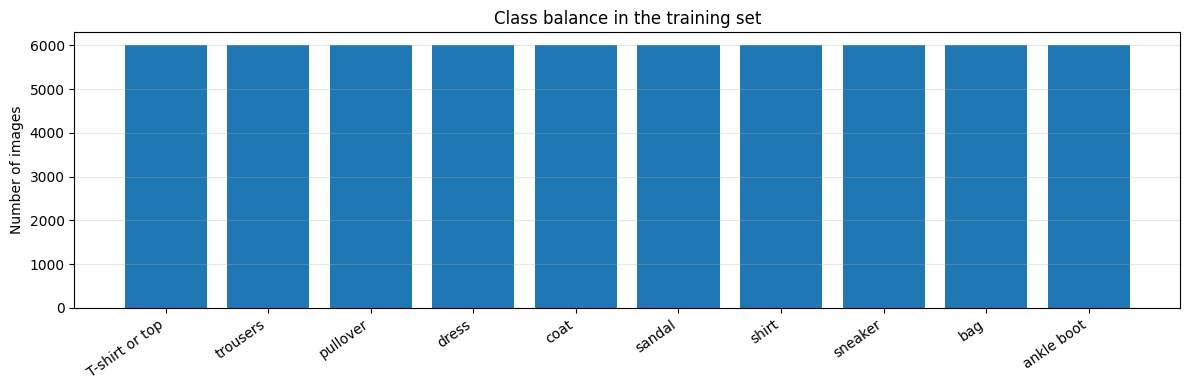

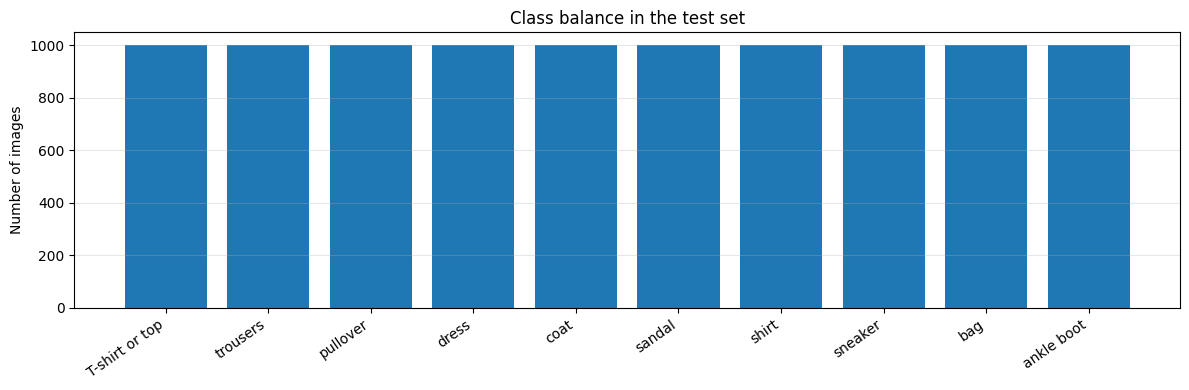

In [7]:
def plot_class_balance(labels: np.ndarray, title: str) -> None:
    """Plots the number of examples in each class."""
    counts = np.bincount(labels, minlength=len(CLASS_NAMES))
    positions = np.arange(len(CLASS_NAMES))

    plt.figure(figsize=(12, 4))
    plt.bar(positions, counts)
    plt.xticks(positions, CLASS_NAMES, rotation=35, ha="right")
    plt.ylabel("Number of images")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_class_balance(train_labels, "Class balance in the training set")
plot_class_balance(test_labels, "Class balance in the test set")


The balance plots show a uniform class distribution. Fashion MNIST contains 6,000 training images and 1,000 test images for each class.

This is an important observation: if any category is generated poorly, the cause should be sought in the architecture, training process, or visual similarity between classes rather than in an imbalance in the source data.


## 8. Exploratory Analysis - Image Examples

This block displays real images from each class. This visualization is required before GAN training because it establishes a visual reference for quality.

The real examples show which properties the model must learn to reproduce: overall silhouette, object width, position in the frame, characteristic details, and noise level. For Fashion MNIST, the correct shape and object placement are more important than fine textures.

This cell also helps identify which classes are likely to be confused. Upper-body garments and shirts are visually similar, while footwear classes are more distinct.


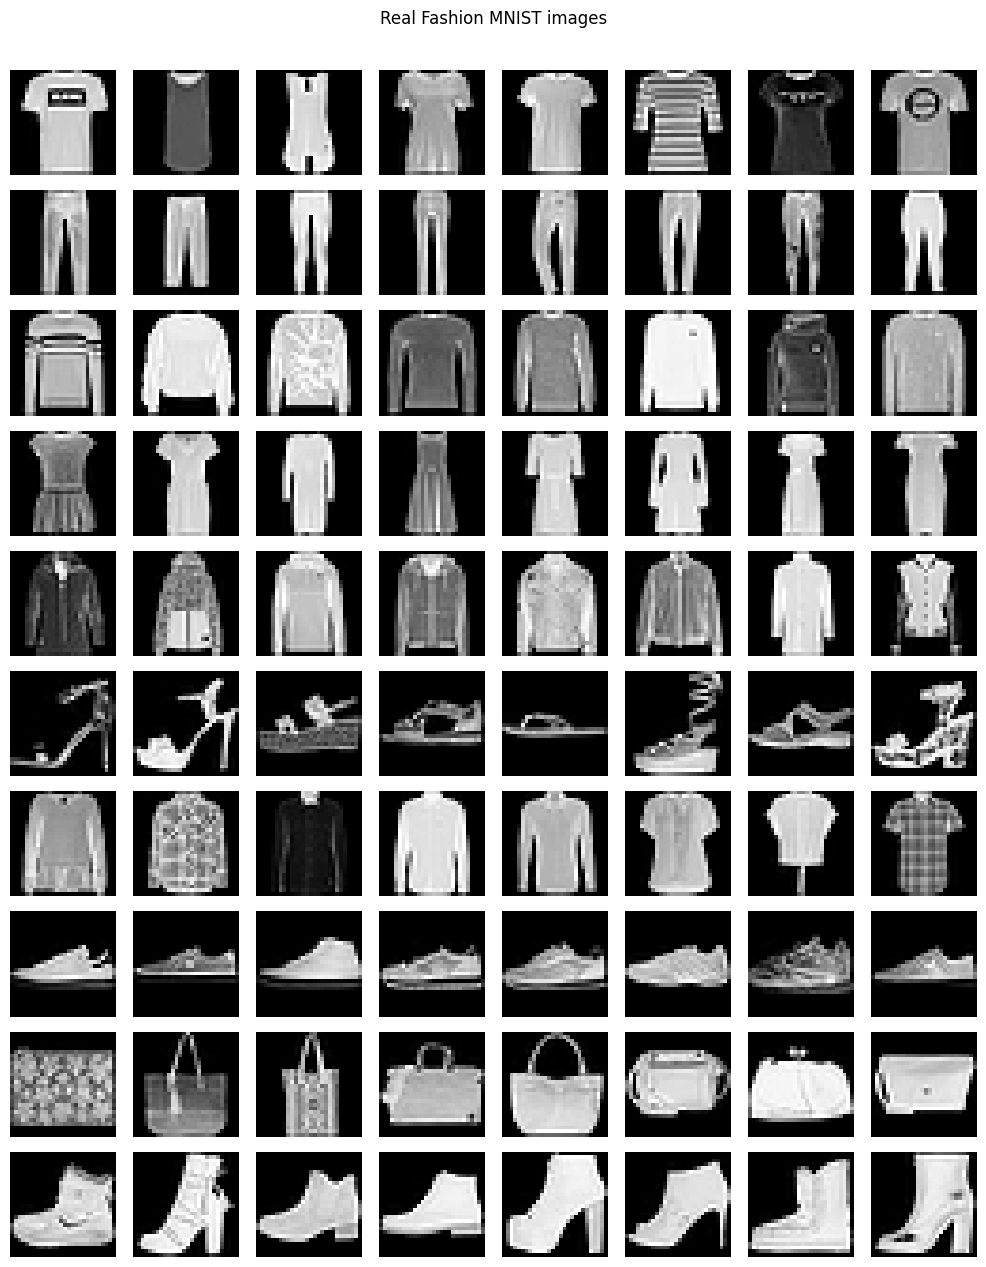

In [8]:
def plot_examples_by_class(images: np.ndarray, labels: np.ndarray, samples_per_class: int = 8) -> None:
    """Shows several real examples from each class."""
    rows = len(CLASS_NAMES)
    cols = samples_per_class
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.25, rows * 1.25))

    for class_id, class_name in enumerate(CLASS_NAMES):
        class_indices = np.where(labels == class_id)[0][:samples_per_class]
        for col, image_index in enumerate(class_indices):
            ax = axes[class_id, col]
            ax.imshow(images[image_index], cmap="gray", vmin=0, vmax=255)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(class_name, rotation=0, labelpad=55, va="center")

    plt.suptitle("Real Fashion MNIST images", y=1.01)
    plt.tight_layout()
    plt.show()


plot_examples_by_class(train_images_raw, train_labels, samples_per_class=8)


The grid of real images shows that the data are well aligned. Objects are centered in the frame, the background is almost black, and the main differences between classes are determined by silhouette.

Footwear and bag classes are easier to separate visually. Upper-body garments are more difficult: `T-shirt or top`, `shirt`, `pullover`, and `coat` have similar shapes, so confusion among them is expected even for a good model.

This visual baseline is needed for the final comparison. Generated images should resemble these real examples not pixel for pixel, but in class silhouette and structure.


## 9. Exploratory Analysis - Brightness and Mean Images

This section analyzes the pixel-brightness distribution and constructs a mean image for each class. The brightness distribution shows how sparse the images are: most of the background is nearly black, while the object occupies the central region.

Mean images reveal the typical silhouette of each class. If the mean image is clear, objects from the class are well aligned in the frame. This is favorable for DCGANs because models learn a distribution more easily when objects have a stable position.

These plots also explain why simple convolutional generators work well for Fashion MNIST. The image size is small, the background is uniform, and the classes differ mainly in outline.


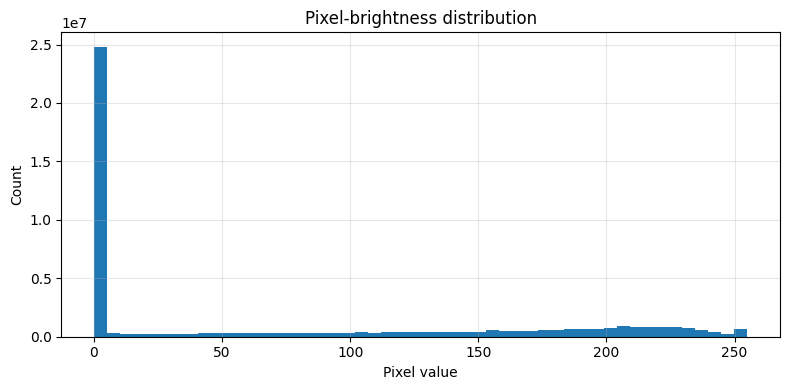

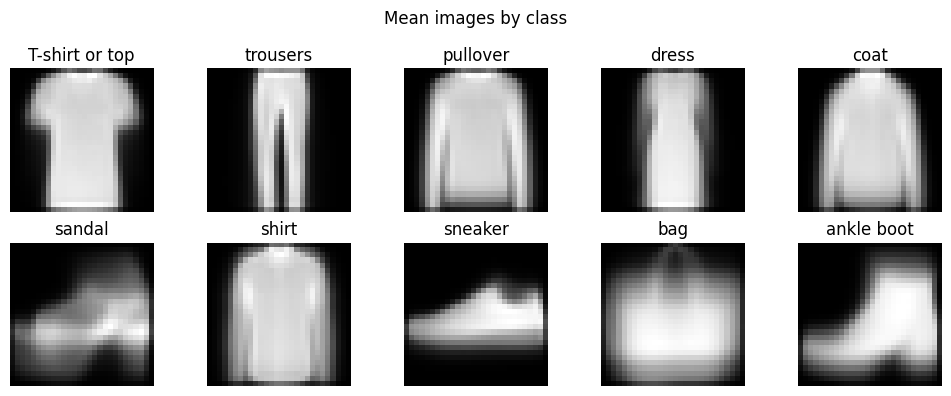

In [9]:
def plot_pixel_statistics(images: np.ndarray) -> None:
    """Shows the distribution of pixel values."""
    plt.figure(figsize=(8, 4))
    plt.hist(images.reshape(-1), bins=50)
    plt.xlabel("Pixel value")
    plt.ylabel("Count")
    plt.title("Pixel-brightness distribution")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_average_images(images: np.ndarray, labels: np.ndarray) -> None:
    """Shows the mean silhouette of each class."""
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.ravel()

    for class_id, class_name in enumerate(CLASS_NAMES):
        class_images = images[labels == class_id]
        mean_image = class_images.mean(axis=0)
        axes[class_id].imshow(mean_image, cmap="gray")
        axes[class_id].set_title(class_name)
        axes[class_id].axis("off")

    plt.suptitle("Mean images by class")
    plt.tight_layout()
    plt.show()


plot_pixel_statistics(train_images_raw)
plot_average_images(train_images_raw, train_labels)


The brightness histogram confirms that the images are sparse. Most pixels belong to the dark background, while informative pixels are concentrated in the object. This is typical for Fashion MNIST.

The class mean images show stable silhouettes. For example, trousers have an elongated vertical shape, a bag has a compact body with a handle, and footwear has a horizontal silhouette. This structure makes conditional generation easier.

For the GAN, this means that the model must learn class geometry first. Excessive noisy textures will be visible in the total-variation metric and in the visual grids.


## 10. Data Normalization

The GAN and the evaluation classifier use different input ranges. For the generator, images are mapped to `[-1, 1]` because the final generator layer uses `tanh`. For the classifier, images are mapped to `[0, 1]`, which is natural for convolutional classification.

Separating the normalization pipelines reduces the risk of hidden errors. The generator and discriminator operate at the same scale, while the evaluation classifier receives data in its expected range.

This block also adds an image channel, changing the shape from `28 x 28` to `28 x 28 x 1`. TensorFlow convolutional layers expect an explicit channel dimension.


In [10]:
def normalize_for_gan(images: np.ndarray) -> np.ndarray:
    """Maps images from [0, 255] to [-1, 1]."""
    images = images.astype("float32")
    images = (images - 127.5) / 127.5
    return images[..., np.newaxis]


def normalize_for_classifier(images: np.ndarray) -> np.ndarray:
    """Maps images from [0, 255] to [0, 1]."""
    images = images.astype("float32") / 255.0
    return images[..., np.newaxis]


train_images_gan = normalize_for_gan(train_images_raw)
test_images_gan = normalize_for_gan(test_images_raw)
train_images_classifier = normalize_for_classifier(train_images_raw)
test_images_classifier = normalize_for_classifier(test_images_raw)

print(f"GAN range: {train_images_gan.min():.1f} .. {train_images_gan.max():.1f}")
print(f"Classifier range: {train_images_classifier.min():.1f} .. {train_images_classifier.max():.1f}")


GAN range: -1.0 .. 1.0
Classifier range: 0.0 .. 1.0


The ranges were transformed correctly: the GAN data span `-1.0 .. 1.0`, while the classifier data span `0.0 .. 1.0`.

This is a critical control. If the generator and discriminator received data at different scales, training could become unstable. If the classifier received images in `[-1, 1]`, its validation accuracy and evaluation metrics would become unreliable.


## 11. High-Throughput Data Pipeline

This block creates `tf.data` pipelines for the classifier and the GAN. It uses caching, shuffling, repetition, fixed batch sizes, and prefetching.

The goal is to minimize GPU idle time. If data are delivered slowly, the GPU waits for the CPU and training slows down. Fashion MNIST is small, so caching is especially effective.

For the GAN, `drop_remainder=True` is used so every batch has the same shape. This reduces TensorFlow graph-tracing overhead and stabilizes the custom training loop.


In [11]:
def apply_fast_dataset_options(dataset: tf.data.Dataset) -> tf.data.Dataset:
    """Applies safe tf.data performance settings."""
    options = tf.data.Options()
    options.experimental_deterministic = False
    return dataset.with_options(options)


def build_classifier_dataset(
    images: np.ndarray,
    labels: np.ndarray,
    batch_size: int,
    training: bool,
) -> tf.data.Dataset:
    """Creates a dataset for classifier training or validation."""
    dataset = tf.data.Dataset.from_tensor_slices((images, labels.astype("int32")))
    dataset = dataset.cache()

    if training:
        dataset = dataset.shuffle(len(images), reshuffle_each_iteration=True)

    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return apply_fast_dataset_options(dataset)


def build_gan_dataset(images: np.ndarray, labels: np.ndarray, config: ExperimentConfig) -> tf.data.Dataset:
    """Creates an infinite GAN dataset with a fixed batch size."""
    dataset = tf.data.Dataset.from_tensor_slices((images, labels.astype("int32")))
    dataset = dataset.cache()
    dataset = dataset.shuffle(len(images), reshuffle_each_iteration=True)
    dataset = dataset.repeat()
    dataset = dataset.batch(config.batch_size, drop_remainder=True)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return apply_fast_dataset_options(dataset)


classifier_train_ds = build_classifier_dataset(
    train_images_classifier,
    train_labels,
    CONFIG.classifier_batch_size,
    training=True,
)
classifier_test_ds = build_classifier_dataset(
    test_images_classifier,
    test_labels,
    CONFIG.classifier_batch_size,
    training=False,
)
gan_train_ds = build_gan_dataset(train_images_gan, train_labels, CONFIG)

print("Data pipelines are ready")


Data pipelines are ready


The message `Data pipelines are ready` means that the classifier and GAN datasets were created without errors.

Three properties of this block are important for GPU training. Caching reduces CPU load, prefetching reduces data-wait time, and a fixed batch size stabilizes the TensorFlow graph. As a result, training on the L4 proceeds with consistent epoch duration.


## 12. Evaluation Classifier

This block creates a convolutional Fashion MNIST classifier. The classifier does not participate in the GAN loss. It is used only as an independent quality evaluator after generation.

The classifier serves several purposes: measuring requested-label agreement, constructing the predicted-class distribution, providing a feature space for the FID-like score, and diagnosing class coverage.

This design reduces the risk of fitting the generator to the classifier. The generator receives a learning signal only from the discriminator, while the classifier remains an external measurement instrument.


In [12]:
def build_quality_classifier(config: ExperimentConfig) -> keras.Model:
    """Builds a Fashion MNIST CNN classifier and a feature layer for metrics."""
    inputs = keras.Input(
        shape=(config.image_size, config.image_size, config.channels),
        name="image",
    )

    # The first block extracts simple edges and local structures.
    x = layers.Conv2D(32, kernel_size=3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(32, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.20)(x)

    # The second block captures larger parts of the silhouette.
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # The final block forms a compact feature vector.
    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling2D()(x)
    features = layers.Dense(128, activation="relu", dtype="float32", name="features")(x)
    outputs = layers.Dense(config.num_classes, activation="softmax", dtype="float32", name="probabilities")(features)

    model = keras.Model(inputs, outputs, name="quality_classifier")
    return model


quality_classifier = build_quality_classifier(CONFIG)
quality_classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG.classifier_learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

quality_classifier.summary()


Model: "quality_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Dense)                │ (None, 128)            │        16,51

 Total params: 157,610 (615.66 KB)

 Trainable params: 156,970 (613.16 KB)

 Non-trainable params: 640 (2.50 KB)

The output displays the classifier architecture. The model is compact enough for Fashion MNIST but contains several convolutional blocks, normalization, and a feature layer that is later used to compute the FID-like metric.

The classifier is intentionally not excessively complex. Its role is to evaluate classes and features reliably, not to become a separate primary object of the study.


## 13. Training the Evaluation Classifier

This section trains the classifier that will later be used to evaluate the generators. Standard callbacks are applied: saving the best model, reducing the learning rate on a plateau, and early stopping.

Classifier quality is important for the analysis, but it should not become the goal of the entire project. If the classifier is too weak, class-agreement metrics will be unreliable. If the classifier is strong but is used in the generator loss, there is a risk of generating patterns that are convenient for the classifier but visually poor. The second risk is eliminated here: the classifier only evaluates.

After training, the best saved classifier version according to validation accuracy is loaded.


In [13]:
classifier_checkpoint_path = MODEL_DIR / "quality_classifier.keras"

classifier_callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(classifier_checkpoint_path),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
]

classifier_history_object = quality_classifier.fit(
    classifier_train_ds,
    validation_data=classifier_test_ds,
    epochs=CONFIG.classifier_epochs,
    callbacks=classifier_callbacks,
    verbose=1,
)

classifier_history = pd.DataFrame(classifier_history_object.history)
classifier_history.to_csv(TABLE_DIR / "classifier_history.csv", index=False)

print("Best validation accuracy:", f"{classifier_history['val_accuracy'].max():.4f}")


Epoch 1/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5921 - loss: 1.1798
Epoch 1: val_accuracy improved from None to 0.10000, saving model to /content/dcgan_fashion_mnist_final/models/quality_classifier.keras

Epoch 1: finished saving model to /content/dcgan_fashion_mnist_final/models/quality_classifier.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 46s 214ms/step - accuracy: 0.7239 - loss: 0.7877 - val_accuracy: 0.1000 - val_loss: 5.5241 - learning_rate: 0.0010
Epoch 2/25
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8469 - loss: 0.4234
Epoch 2: val_accuracy improved from 0.10000 to 0.17780, saving model to /content/dcgan_fashion_mnist_final/models/quality_classifier.keras

Epoch 2: finished saving model to /content/dcgan_fashion_mnist_final/models/quality_classifier.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8574 - loss: 0.3946 - val_accuracy: 0.1778 - val_loss: 5.0565 - learning_rate: 0.0010
Epoch 3/25
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accurac

In this run, the evaluation classifier reached a best validation accuracy of **0.9317** at epoch 25. The corresponding validation loss was **0.1989**, while the final training accuracy was **0.9431**. The gap between training and validation accuracy remained small, so the classifier retained good generalization.

The first several epochs show a characteristic adaptation phase. Training accuracy rises immediately, while validation accuracy starts at 0.10 and then increases sharply to 0.7856 at epoch 5 and 0.9056 at epoch 9. This delayed validation improvement is consistent with the stabilization of Batch Normalization statistics and the gradual formation of useful convolutional features.

`ReduceLROnPlateau` reduced the learning rate from `1e-3` to `5e-4` after epoch 13 and then to `2.5e-4` after epoch 19. Both reductions were useful: validation accuracy later improved to 0.9277 at epoch 16, 0.9290 at epoch 23, and finally 0.9317 at epoch 25.

The classifier is sufficiently reliable for measuring class coverage, requested-label agreement, and feature-space distances. Its predictions should still be interpreted carefully for visually similar upper-body classes such as `T-shirt or top`, `pullover`, `coat`, and `shirt`.


## 14. Classifier Training Curves

This block plots classifier accuracy and loss for the training and validation sets.

The plots are needed to verify two points. First, the classifier must genuinely learn and reach high validation accuracy. Second, the gap between training and validation should not be excessive; otherwise, the classifier would generalize poorly and become an unreliable generation evaluator.

This classifier will later be used as part of the evaluation system, so its dynamics must be transparent and verified.


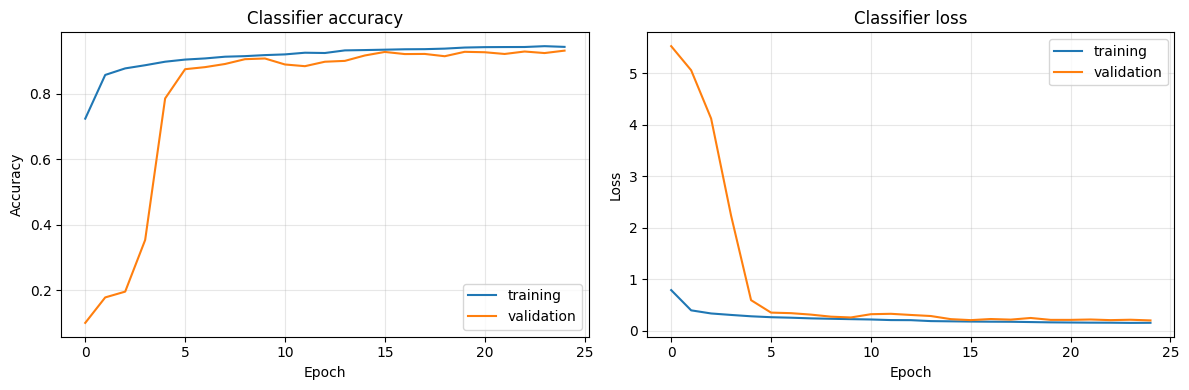

In [14]:
def plot_classifier_history(history: pd.DataFrame) -> None:
    """Shows classifier accuracy and loss dynamics."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["accuracy"], label="training")
    axes[0].plot(history["val_accuracy"], label="validation")
    axes[0].set_title("Classifier accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history["loss"], label="training")
    axes[1].plot(history["val_loss"], label="validation")
    axes[1].set_title("Classifier loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_classifier_history(classifier_history)


The accuracy curves show a stable learning process. Training accuracy increases from **0.7239** in the first epoch to **0.9431** in the final epoch. Validation accuracy initially lags behind, but rises from **0.1000** to **0.7856** by epoch 5, exceeds **0.90** at epoch 9, and reaches the best value of **0.9317** at epoch 25.

The temporary validation fluctuations around epochs 10-14 do not indicate a failure. During this interval, training accuracy continues to improve while the validation curve oscillates between approximately 0.88 and 0.91. After the first learning-rate reduction, the validation metric recovers and establishes a new maximum.

The loss curves support the same interpretation. Training loss falls from **0.7877** to **0.1529**. Validation loss decreases from **5.5241** in the first epoch to **0.1989** in the final epoch. The very large initial validation loss is temporary and disappears once the model's internal statistics and features stabilize.

No critical overfitting is visible. The final difference between training and validation accuracy is about 1.1 percentage points, and validation loss remains controlled. The classifier can therefore be used as an independent evaluation instrument for the two GANs.


## 15. Preparing Real-Data Features

This block extracts an intermediate feature layer from the trained classifier. These features are used to compare real and generated images in a more informative space than raw pixels.

It also computes baseline statistics for real images: mean total variation, the share of strong neighboring-pixel transitions, and the mean standard deviation of features. These values are used to normalize generator-quality metrics.

This approach makes the evaluation more robust. For example, if a generator creates noisy images, pixel brightness may look plausible, but total variation and the FID-like score will deteriorate.


In [15]:
feature_extractor = keras.Model(
    quality_classifier.input,
    quality_classifier.get_layer("features").output,
    name="quality_feature_extractor",
)


def gan_to_classifier_range(images: np.ndarray) -> np.ndarray:
    """Maps images from [-1, 1] to [0, 1]."""
    images = np.asarray(images, dtype="float32")
    return np.clip((images + 1.0) / 2.0, 0.0, 1.0)


def extract_probabilities_and_features(
    classifier: keras.Model,
    extractor: keras.Model,
    images_01: np.ndarray,
    batch_size: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """Computes class probabilities and features for an image array."""
    probabilities_batches: List[np.ndarray] = []
    feature_batches: List[np.ndarray] = []

    for start in range(0, len(images_01), batch_size):
        batch = tf.convert_to_tensor(images_01[start : start + batch_size], dtype=tf.float32)
        probabilities = classifier(batch, training=False)
        features = extractor(batch, training=False)
        probabilities_batches.append(probabilities.numpy().astype("float32"))
        feature_batches.append(features.numpy().astype("float32"))

    return np.concatenate(probabilities_batches, axis=0), np.concatenate(feature_batches, axis=0)


def covariance_with_regularization(features: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Computes a covariance matrix with small diagonal regularization."""
    covariance = np.cov(features, rowvar=False)
    covariance = np.atleast_2d(covariance).astype("float64")
    covariance += np.eye(covariance.shape[0], dtype="float64") * eps
    return covariance


def frechet_distance_from_features(real_features: np.ndarray, generated_features: np.ndarray) -> float:
    """Computes the FID-like distance between real- and generated-image features."""
    real_mean = real_features.mean(axis=0).astype("float64")
    generated_mean = generated_features.mean(axis=0).astype("float64")
    real_covariance = covariance_with_regularization(real_features)
    generated_covariance = covariance_with_regularization(generated_features)

    covariance_product_sqrt = linalg.sqrtm(real_covariance @ generated_covariance)
    if np.iscomplexobj(covariance_product_sqrt):
        covariance_product_sqrt = covariance_product_sqrt.real

    if not np.all(np.isfinite(covariance_product_sqrt)):
        offset = np.eye(real_covariance.shape[0], dtype="float64") * 1e-4
        covariance_product_sqrt = linalg.sqrtm((real_covariance + offset) @ (generated_covariance + offset))
        if np.iscomplexobj(covariance_product_sqrt):
            covariance_product_sqrt = covariance_product_sqrt.real

    mean_difference = real_mean - generated_mean
    distance = mean_difference @ mean_difference
    distance += np.trace(real_covariance + generated_covariance - 2.0 * covariance_product_sqrt)
    return float(max(distance, 0.0))


def total_variation_mean(images: np.ndarray) -> float:
    """Estimates the mean variation between neighboring pixels."""
    images = np.asarray(images, dtype="float32")
    horizontal = np.abs(images[:, :, 1:, :] - images[:, :, :-1, :]).mean()
    vertical = np.abs(images[:, 1:, :, :] - images[:, :-1, :, :]).mean()
    return float(horizontal + vertical)


def high_contrast_neighbor_share(images: np.ndarray, threshold: float = 0.55) -> float:
    """Computes the share of neighboring pixels with a very large brightness transition."""
    images = np.asarray(images, dtype="float32")
    horizontal = np.abs(images[:, :, 1:, :] - images[:, :, :-1, :]) > threshold
    vertical = np.abs(images[:, 1:, :, :] - images[:, :-1, :, :]) > threshold
    return float(np.concatenate([horizontal.reshape(-1), vertical.reshape(-1)]).mean())


real_reference_images = test_images_gan.astype("float32")
real_reference_images_01 = gan_to_classifier_range(real_reference_images)
real_probabilities, real_features = extract_probabilities_and_features(
    quality_classifier,
    feature_extractor,
    real_reference_images_01,
    batch_size=CONFIG.classifier_batch_size,
)

REAL_TV = total_variation_mean(real_reference_images_01)
REAL_HIGH_CONTRAST = high_contrast_neighbor_share(real_reference_images_01)
REAL_FEATURE_STD = float(np.mean(np.std(real_features, axis=0)) + 1e-8)

print(f"Mean total variation of real images: {REAL_TV:.4f}")
print(f"Share of strong transitions in real images: {REAL_HIGH_CONTRAST:.4f}")
print(f"Mean feature standard deviation: {REAL_FEATURE_STD:.4f}")


Mean total variation of real images: 0.1560
Share of strong transitions in real images: 0.0359
Mean feature standard deviation: 0.7074


The real-data feature calculation produced three reference values:

- mean total variation: **0.1560**;
- share of strong neighboring-pixel transitions: **0.0359**;
- mean feature standard deviation: **0.7074**.

These values define the empirical structure of real Fashion MNIST images. They are later used to normalize the generator diagnostics rather than comparing generated images with an abstract target.

A total-variation ratio close to 1 indicates that generated images have a similar amount of local pixel change to the real data. A strong-transition ratio close to 1 indicates that the frequency of sharp boundaries is realistic. The feature-standard-deviation reference is used to assess whether the generated set preserves enough diversity in the classifier's feature space.

Fixing these real-data statistics before GAN training makes the final comparison reproducible and prevents the two generators from being judged by different baselines.


## 16. Generator Quality Evaluator

This section creates functions that convert a set of generated images into numerical metrics. The evaluator combines several aspects of quality: proximity to the real distribution, class coverage, requested-label agreement, feature diversity, and the level of pixel artifacts.

A separate aggregate score is needed to select the best EMA generator during training. The aggregate score does not replace the detailed metrics. It is a convenient summary, while interpretation is based on the full table.

The metrics are designed not to reward visually poor generation. For example, excessively sharp neighboring-pixel transitions and inflated total variation reduce the score even when class recognition is strong.


In [16]:
def normalized_entropy(probabilities: np.ndarray) -> float:
    """Computes distribution entropy normalized to [0, 1]."""
    probabilities = np.asarray(probabilities, dtype="float64")
    probabilities = probabilities[probabilities > 0]
    if len(probabilities) == 0:
        return 0.0
    entropy = -np.sum(probabilities * np.log(probabilities))
    return float(entropy / np.log(CONFIG.num_classes))


def closeness_to_one_score(value: float, eps: float = 1e-8) -> float:
    """Returns 1.0 when value is close to 1.0 and decreases for large deviations."""
    value = max(float(value), eps)
    return float(np.exp(-abs(np.log(value))))


def build_balanced_labels(sample_count: int, num_classes: int, seed: Optional[int] = None) -> np.ndarray:
    """Creates an approximately uniform label array of the requested length."""
    labels = np.arange(sample_count, dtype="int32") % num_classes
    if seed is not None:
        rng = np.random.default_rng(seed)
        rng.shuffle(labels)
    return labels


class QualityEvaluator:
    """Computes quality metrics for a conditional generator."""

    def __init__(
        self,
        classifier: keras.Model,
        extractor: keras.Model,
        real_features: np.ndarray,
        config: ExperimentConfig,
    ) -> None:
        self.classifier = classifier
        self.extractor = extractor
        self.real_features = real_features
        self.config = config

        # A fixed set of noise vectors and labels is used to select the best model.
        # This reduces random quality fluctuations between epochs.
        self.reference_sample_count = max(config.eval_samples, config.final_eval_samples)
        rng = np.random.default_rng(config.seed + 2028)
        self.reference_labels = build_balanced_labels(
            self.reference_sample_count,
            config.num_classes,
            seed=config.seed + 2029,
        )
        self.reference_noise = rng.normal(
            size=(self.reference_sample_count, config.latent_dim),
        ).astype("float32")

    def generate_images(
        self,
        generator: keras.Model,
        labels: np.ndarray,
        noise_vectors: np.ndarray,
        batch_size: int,
    ) -> np.ndarray:
        """Generates images in batches to avoid exhausting GPU memory."""
        generated_batches: List[np.ndarray] = []

        for start in range(0, len(labels), batch_size):
            label_batch = labels[start : start + batch_size].astype("int32")
            noise_batch = noise_vectors[start : start + len(label_batch)].astype("float32")
            images = generator(
                [tf.convert_to_tensor(noise_batch), tf.convert_to_tensor(label_batch)],
                training=False,
            )
            generated_batches.append(images.numpy().astype("float32"))

        return np.concatenate(generated_batches, axis=0)

    def evaluate(
        self,
        generator: keras.Model,
        sample_count: Optional[int] = None,
        return_details: bool = False,
    ):
        """Returns a metric dictionary and, when requested, per-class details."""
        count = int(sample_count or self.config.eval_samples)
        requested_labels = self.reference_labels[:count]
        noise_vectors = self.reference_noise[:count]
        generated_images = self.generate_images(
            generator,
            requested_labels,
            noise_vectors=noise_vectors,
            batch_size=self.config.batch_size,
        )
        generated_images_01 = gan_to_classifier_range(generated_images)

        probabilities, features = extract_probabilities_and_features(
            self.classifier,
            self.extractor,
            generated_images_01,
            batch_size=self.config.classifier_batch_size,
        )
        predicted_labels = probabilities.argmax(axis=1).astype("int32")
        class_counts = np.bincount(predicted_labels, minlength=self.config.num_classes)
        class_shares = class_counts / max(1, class_counts.sum())

        condition_match_by_class = []
        for class_id in range(self.config.num_classes):
            mask = requested_labels == class_id
            match = float((predicted_labels[mask] == class_id).mean()) if mask.any() else 0.0
            condition_match_by_class.append(match)

        fid_like = frechet_distance_from_features(self.real_features, features)
        feature_diversity_ratio = float(np.mean(np.std(features, axis=0)) / REAL_FEATURE_STD)
        tv_ratio = total_variation_mean(generated_images_01) / max(REAL_TV, 1e-8)
        high_contrast_ratio = high_contrast_neighbor_share(generated_images_01) / max(REAL_HIGH_CONTRAST, 1e-8)

        coverage_entropy = normalized_entropy(class_shares)
        min_class_share = float(class_shares.min())
        missing_class_count = int(np.sum(class_counts == 0))
        label_match_rate = float((predicted_labels == requested_labels).mean())
        min_condition_match = float(np.min(condition_match_by_class))
        mean_confidence = float(probabilities.max(axis=1).mean())

        # Normalized component scores used to form one aggregate quality score.
        fid_score = 1.0 / (1.0 + fid_like / 15.0)
        min_share_score = min(1.0, min_class_share / (0.5 / self.config.num_classes))
        diversity_score = closeness_to_one_score(feature_diversity_ratio)
        tv_score = closeness_to_one_score(tv_ratio)
        contrast_score = closeness_to_one_score(high_contrast_ratio)
        realism_score = 0.55 * tv_score + 0.45 * contrast_score

        quality_score = (
            0.35 * fid_score
            + 0.15 * coverage_entropy
            + 0.15 * label_match_rate
            + 0.10 * min_share_score
            + 0.10 * diversity_score
            + 0.15 * realism_score
        )

        metrics = {
            "fid_like": float(fid_like),
            "coverage_entropy": float(coverage_entropy),
            "label_match_rate": float(label_match_rate),
            "min_class_share": float(min_class_share),
            "missing_class_count": float(missing_class_count),
            "min_condition_match": float(min_condition_match),
            "feature_diversity_ratio": float(feature_diversity_ratio),
            "tv_ratio": float(tv_ratio),
            "high_contrast_ratio": float(high_contrast_ratio),
            "mean_confidence": float(mean_confidence),
            "quality_score": float(quality_score),
        }

        if not return_details:
            return metrics

        details = {
            "requested_labels": requested_labels,
            "predicted_labels": predicted_labels,
            "probabilities": probabilities,
            "features": features,
            "images": generated_images,
            "class_shares": class_shares,
            "condition_match_by_class": np.array(condition_match_by_class, dtype="float32"),
        }
        return metrics, details


quality_evaluator = QualityEvaluator(quality_classifier, feature_extractor, real_features, CONFIG)
print("Quality evaluator is ready")


Quality evaluator is ready


The message `Quality evaluator is ready` means that the metric functions and the aggregate quality score are available for training and final comparison.

An important methodological property is that the aggregate score penalizes not only poor class coverage, but also pixel artifacts. This protects the experiment from a false success in which the model fools the classifier but looks visually poor.


## 17. Generator Architectures

This block defines the two generator architectures being compared. Both models are conditional. They receive a latent vector and a class label as input, then create an image of the requested category.

The baseline model uses a compact DCGAN structure with transposed convolutions. The enhanced model uses a deeper path with upsampling and convolutional refinement to reduce coarse artifacts and give the generator greater expressive capacity.

The research hypothesis is that the enhanced architecture may improve visual quality, but its greater complexity may also make it slower and not necessarily better for a small 28 x 28 image.


In [17]:
def dcgan_initializer() -> keras.initializers.Initializer:
    """Returns an initializer traditionally used for DCGAN."""
    return keras.initializers.RandomNormal(mean=0.0, stddev=0.02)


def build_label_condition(noise_input: keras.Input, label_input: keras.Input, config: ExperimentConfig, embedding_dim: int) -> tf.Tensor:
    """Combines noise with a class vector."""
    label_embedding = layers.Embedding(
        input_dim=config.num_classes,
        output_dim=embedding_dim,
        embeddings_initializer=dcgan_initializer(),
    )(label_input)
    label_embedding = layers.Flatten()(label_embedding)
    return layers.Concatenate()([noise_input, label_embedding])


def build_basic_conditional_generator(config: ExperimentConfig) -> keras.Model:
    """Builds a compact conditional generator with transposed convolutions."""
    noise_input = keras.Input(shape=(config.latent_dim,), name="noise")
    label_input = keras.Input(shape=(), dtype=tf.int32, name="label")
    conditioned_input = build_label_condition(noise_input, label_input, config, embedding_dim=48)

    x = layers.Dense(7 * 7 * 128, use_bias=False, kernel_initializer=dcgan_initializer())(conditioned_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Reshape((7, 7, 128))(x)

    x = layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    outputs = layers.Conv2D(
        config.channels,
        kernel_size=5,
        padding="same",
        activation="tanh",
        dtype="float32",
        kernel_initializer=dcgan_initializer(),
        name="generated_image",
    )(x)

    return keras.Model([noise_input, label_input], outputs, name="basic_conditional_generator")


def build_enhanced_conditional_generator(config: ExperimentConfig) -> keras.Model:
    """Builds an enhanced generator with upsampling and convolutional refinement."""
    noise_input = keras.Input(shape=(config.latent_dim,), name="noise")
    label_input = keras.Input(shape=(), dtype=tf.int32, name="label")
    conditioned_input = build_label_condition(noise_input, label_input, config, embedding_dim=64)

    x = layers.Dense(7 * 7 * 256, use_bias=False, kernel_initializer=dcgan_initializer())(conditioned_input)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Reshape((7, 7, 256))(x)

    # Convolutional refinement at low resolution helps form the overall silhouette.
    x = layers.Conv2D(256, kernel_size=3, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Transition from 7 x 7 to 14 x 14 without transposed convolution.
    x = layers.UpSampling2D(size=2)(x)
    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Transition from 14 x 14 to 28 x 28 followed by final contour refinement.
    x = layers.UpSampling2D(size=2)(x)
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False, kernel_initializer=dcgan_initializer())(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    outputs = layers.Conv2D(
        config.channels,
        kernel_size=5,
        padding="same",
        activation="tanh",
        dtype="float32",
        kernel_initializer=dcgan_initializer(),
        name="generated_image",
    )(x)

    return keras.Model([noise_input, label_input], outputs, name="enhanced_conditional_generator")


The main comparison is built around the difference between the generators. The baseline generator is lighter and faster, while the enhanced generator has greater expressive capacity but requires more computation. The subsequent results will show whether this additional complexity is justified.


## 18. Conditional Projection Discriminator

This block defines a discriminator that evaluates not only image realism, but also the consistency of an image with the requested class label.

The projection mechanism works as follows: the discriminator extracts image features, obtains a class embedding, and adds the dot product of the features and the embedding to the final score. If the image resembles the requested class, the score should be higher.

This discriminator gives the generator a strong conditional signal without an external classifier-based loss. This is an important methodological choice: the model learns through competition with the discriminator, while the classifier remains an independent evaluator.


In [18]:
def projection_dot(tensors: List[tf.Tensor]) -> tf.Tensor:
    """Computes the dot product of image features and the class vector."""
    features, label_embedding = tensors
    features = tf.cast(features, tf.float32)
    label_embedding = tf.cast(label_embedding, tf.float32)
    return tf.reduce_sum(features * label_embedding, axis=1, keepdims=True)


def build_projection_discriminator(config: ExperimentConfig, feature_dim: int = 256) -> keras.Model:
    """Builds a conditional discriminator with class projection."""
    image_input = keras.Input(
        shape=(config.image_size, config.image_size, config.channels),
        name="image",
    )
    label_input = keras.Input(shape=(), dtype=tf.int32, name="label")

    # BatchNormalization is not used in the discriminator to avoid mixing real and fake statistics.
    x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same", kernel_initializer=dcgan_initializer())(image_input)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same", kernel_initializer=dcgan_initializer())(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv2D(256, kernel_size=3, strides=2, padding="same", kernel_initializer=dcgan_initializer())(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Flatten()(x)
    features = layers.Dense(feature_dim, kernel_initializer=dcgan_initializer())(x)
    features = layers.LeakyReLU(negative_slope=0.2)(features)
    features = layers.Activation("linear", dtype="float32", name="image_features")(features)

    unconditional_score = layers.Dense(1, dtype="float32", kernel_initializer=dcgan_initializer(), name="unconditional_score")(features)
    label_embedding = layers.Embedding(
        input_dim=config.num_classes,
        output_dim=feature_dim,
        embeddings_initializer=dcgan_initializer(),
        dtype="float32",
        name="label_embedding",
    )(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    projection_score = layers.Lambda(projection_dot, dtype="float32", name="projection_score")([features, label_embedding])
    outputs = layers.Add(dtype="float32", name="discriminator_score")([unconditional_score, projection_score])

    return keras.Model([image_input, label_input], outputs, name="projection_discriminator")


@dataclass(frozen=True)
class ModelSpec:
    """Describes one model in the comparison."""

    key: str
    title: str
    generator_builder: Callable[[ExperimentConfig], keras.Model]


MODEL_SPECS = [
    ModelSpec("basic", "Baseline conditional DCGAN", build_basic_conditional_generator),
    ModelSpec("enhanced", "Enhanced conditional DCGAN", build_enhanced_conditional_generator),
]

# Quick inspection of model sizes.
for spec in MODEL_SPECS:
    generator = spec.generator_builder(CONFIG)
    discriminator = build_projection_discriminator(CONFIG)
    print(f"{spec.title}: generator parameters = {generator.count_params():,}, discriminator parameters = {discriminator.count_params():,}")


Baseline conditional DCGAN: generator parameters = 1,525,025, discriminator parameters = 1,479,105
Enhanced conditional DCGAN: generator parameters = 3,606,209, discriminator parameters = 1,479,105


In the reference run, the baseline generator has **1,525,025** parameters, the enhanced generator has **3,606,209** parameters, and the discriminator is identical for both models with **1,479,105** parameters.

This comparison is valid because the difference between the models lies specifically in the generator. The enhanced model is more than twice as large, so it must show a noticeable quality improvement to justify the added complexity.


## 19. Loss Functions and Discriminator Augmentation

This section defines the GAN loss functions and light augmentation for the discriminator. Hinge loss is used because it works reliably with discriminators that do not have a final sigmoid and is well suited to the conditional projection scheme.

The discriminator receives three types of signals: real images with the correct label, generated images with the requested label, and real images with an incorrect label. The third signal helps the discriminator account for the class condition rather than only image realism.

The augmentation adds small shifts and decaying noise. This reduces the risk of discriminator overfitting and makes the generator's optimization landscape smoother.


In [19]:
def discriminator_hinge_loss(
    real_scores: tf.Tensor,
    fake_scores: tf.Tensor,
    wrong_scores: tf.Tensor,
    wrong_label_weight: float,
) -> tf.Tensor:
    """Computes the discriminator hinge loss."""
    real_loss = tf.reduce_mean(tf.nn.relu(1.0 - tf.cast(real_scores, tf.float32)))
    fake_loss = tf.reduce_mean(tf.nn.relu(1.0 + tf.cast(fake_scores, tf.float32)))
    wrong_loss = tf.reduce_mean(tf.nn.relu(1.0 + tf.cast(wrong_scores, tf.float32)))
    return real_loss + fake_loss + wrong_label_weight * wrong_loss


def generator_hinge_loss(fake_scores: tf.Tensor) -> tf.Tensor:
    """Computes the generator hinge loss."""
    return -tf.reduce_mean(tf.cast(fake_scores, tf.float32))


def generator_total_variation_loss(images: tf.Tensor) -> tf.Tensor:
    """Computes the mean total variation of generated images."""
    images = tf.cast(images, tf.float32)
    horizontal = tf.reduce_mean(tf.abs(images[:, :, 1:, :] - images[:, :, :-1, :]))
    vertical = tf.reduce_mean(tf.abs(images[:, 1:, :, :] - images[:, :-1, :, :]))
    return horizontal + vertical


def make_balanced_fake_labels(batch_size: tf.Tensor, num_classes: int) -> tf.Tensor:
    """Creates an approximately uniform label set for generated images."""
    labels = tf.math.floormod(tf.range(batch_size), num_classes)
    labels = tf.random.shuffle(tf.cast(labels, tf.int32))
    return labels


def make_wrong_labels(real_labels: tf.Tensor, num_classes: int) -> tf.Tensor:
    """Creates incorrect labels guaranteed to differ from the true labels."""
    offsets = tf.random.uniform(tf.shape(real_labels), minval=1, maxval=num_classes, dtype=tf.int32)
    return tf.math.floormod(tf.cast(real_labels, tf.int32) + offsets, num_classes)


def random_translate_batch(images: tf.Tensor, max_translation: int) -> tf.Tensor:
    """Shifts the entire batch by a random number of pixels without tf.map_fn."""
    if max_translation <= 0:
        return images

    image_shape = tf.shape(images)
    padding = [[0, 0], [max_translation, max_translation], [max_translation, max_translation], [0, 0]]
    padded_images = tf.pad(images, padding, mode="REFLECT")
    offset_y = tf.random.uniform([], minval=0, maxval=2 * max_translation + 1, dtype=tf.int32)
    offset_x = tf.random.uniform([], minval=0, maxval=2 * max_translation + 1, dtype=tf.int32)
    return tf.slice(padded_images, [0, offset_y, offset_x, 0], image_shape)


def augment_for_discriminator(
    images: tf.Tensor,
    probability: float,
    max_translation: int,
    noise_std: tf.Tensor,
) -> tf.Tensor:
    """Applies light augmentation and noise before the discriminator."""
    images = tf.cast(images, tf.float32)

    images = tf.cond(
        tf.random.uniform([]) < probability,
        lambda: random_translate_batch(images, max_translation),
        lambda: images,
    )

    noise = tf.random.normal(tf.shape(images), mean=0.0, stddev=tf.cast(noise_std, tf.float32), dtype=tf.float32)
    images = images + noise
    return tf.clip_by_value(images, -1.0, 1.0)


This cell defines the mathematical part of training. Successful execution means that the discriminator loss, generator loss, and augmentation functions are available to the trainer class.

Hinge loss uses raw discriminator scores, so the `real` and `fake` values in the logs are not probabilities. They should be interpreted as relative scores: higher for real pairs and lower for generated or incorrectly labeled pairs.


## 20. Optimizers and Gradient Diagnostics

This block creates optimizers and gradient-diagnostic functions. For a GAN, the absence of runtime errors is not enough; the weights must actually be updated. Therefore, the notebook tracks the share of existing gradients, the share of finite gradients, and the norms of scaled gradients.

With `mixed_float16`, the optimizer may use loss scaling. Gradient norms should therefore be interpreted as a diagnostic signal rather than an absolute physical quantity. More reliable stability indicators are the share of existing gradients, the share of finite gradients, and the absence of `NaN` values in the losses.

Gradient diagnostics are needed to avoid mistaking the formal execution of a loop for genuine learning.


In [20]:
def build_optimizer(learning_rate: float, config: ExperimentConfig) -> keras.optimizers.Optimizer:
    """Creates Adam and wraps it in LossScaleOptimizer when needed."""
    base_optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate,
        beta_1=config.adam_beta_1,
        beta_2=config.adam_beta_2,
        epsilon=1e-8,
        global_clipnorm=config.global_clipnorm,
    )

    if config.mixed_precision and tf.config.list_physical_devices("GPU"):
        return tf.keras.mixed_precision.LossScaleOptimizer(base_optimizer)
    return base_optimizer


def scale_loss_if_needed(optimizer: keras.optimizers.Optimizer, loss: tf.Tensor) -> tf.Tensor:
    """Scales the loss for mixed precision when supported by the optimizer."""
    return optimizer.scale_loss(loss) if hasattr(optimizer, "scale_loss") else loss


def unwrap_optimizer(optimizer: keras.optimizers.Optimizer) -> keras.optimizers.Optimizer:
    """Returns the inner optimizer when LossScaleOptimizer is used."""
    if hasattr(optimizer, "inner_optimizer"):
        return optimizer.inner_optimizer
    if hasattr(optimizer, "_optimizer"):
        return optimizer._optimizer
    return optimizer


def get_learning_rate(optimizer: keras.optimizers.Optimizer) -> float:
    """Reads the current learning rate."""
    base_optimizer = unwrap_optimizer(optimizer)
    learning_rate = base_optimizer.learning_rate
    try:
        return float(tf.keras.backend.get_value(learning_rate))
    except TypeError:
        return float(learning_rate)


def set_learning_rate(optimizer: keras.optimizers.Optimizer, value: float) -> None:
    """Updates the optimizer learning rate."""
    base_optimizer = unwrap_optimizer(optimizer)
    learning_rate = base_optimizer.learning_rate
    if hasattr(learning_rate, "assign"):
        learning_rate.assign(value)
    else:
        base_optimizer.learning_rate = value


def gradient_values(gradient: tf.Tensor) -> tf.Tensor:
    """Returns a dense gradient value or the values from IndexedSlices."""
    if isinstance(gradient, tf.IndexedSlices):
        return gradient.values
    return gradient


def gradient_statistics(gradients: List[Optional[tf.Tensor]]) -> Dict[str, tf.Tensor]:
    """Computes gradient presence, finiteness, and norms."""
    total_count = max(len(gradients), 1)
    present_gradients = [gradient for gradient in gradients if gradient is not None]
    present_ratio = tf.constant(len(present_gradients) / total_count, dtype=tf.float32)

    if not present_gradients:
        return {
            "present_ratio": present_ratio,
            "finite_ratio": tf.constant(0.0, dtype=tf.float32),
            "global_norm": tf.constant(0.0, dtype=tf.float32),
            "max_abs": tf.constant(0.0, dtype=tf.float32),
        }

    gradient_tensors = [tf.cast(gradient_values(gradient), tf.float32) for gradient in present_gradients]
    finite_flags = [tf.reduce_all(tf.math.is_finite(tensor)) for tensor in gradient_tensors]
    max_abs_values = [tf.reduce_max(tf.abs(tensor)) for tensor in gradient_tensors]

    return {
        "present_ratio": present_ratio,
        "finite_ratio": tf.reduce_mean(tf.cast(tf.stack(finite_flags), tf.float32)),
        "global_norm": tf.linalg.global_norm(gradient_tensors),
        "max_abs": tf.reduce_max(tf.stack(max_abs_values)),
    }


def model_weights_are_finite(model: keras.Model) -> bool:
    """Checks that all model weights are finite."""
    return all(np.all(np.isfinite(weight.numpy())) for weight in model.weights)


The optimization and diagnostic functions have been created. They will later be used in the one-step validation and in full GAN training.

When interpreting gradient plots, it is important to remember that mixed precision can make the norms look jagged because of scaling. The final analysis therefore gives priority to the share of existing gradients, the share of finite gradients, and the absence of non-finite loss values.


## 21. Callbacks for the Custom Training Loop

This block defines callbacks for the custom GAN training loop. They perform three tasks: save the best weights, reduce the learning rate on a plateau, and stop training after a prolonged lack of improvement.

The best model is not the last model, but the EMA generator with the highest aggregate quality score. This is important for GANs because the latest weights can be worse due to the oscillatory nature of adversarial training.

The callback logic is separated from the trainer class. This separation keeps the code cleaner: training, best-model preservation, and learning-rate control address different aspects of the experiment.


In [21]:
class BestModelSaver:
    """Stores the best generator, EMA-generator, and discriminator weights."""

    def __init__(self, model_key: str, model_title: str, model_dir: Path, min_delta: float) -> None:
        self.model_key = model_key
        self.model_title = model_title
        self.model_dir = model_dir
        self.min_delta = min_delta
        self.best_score = -np.inf
        self.best_epoch = 0
        self.best_logs: Dict[str, float] = {}
        self.generator_weights: Optional[List[np.ndarray]] = None
        self.ema_generator_weights: Optional[List[np.ndarray]] = None
        self.discriminator_weights: Optional[List[np.ndarray]] = None

    def update(self, epoch: int, score: float, trainer: "ConditionalGanTrainer", logs: Dict[str, float]) -> bool:
        """Updates the best snapshot when quality improves."""
        if not np.isfinite(score):
            return False

        improved = score > self.best_score + self.min_delta
        if not improved:
            return False

        self.best_score = float(score)
        self.best_epoch = int(epoch)
        self.best_logs = dict(logs)
        self.generator_weights = trainer.generator.get_weights()
        self.ema_generator_weights = trainer.ema_generator.get_weights()
        self.discriminator_weights = trainer.discriminator.get_weights()

        trainer.generator.save_weights(self.model_dir / f"{self.model_key}_generator_best.weights.h5")
        trainer.ema_generator.save_weights(self.model_dir / f"{self.model_key}_ema_generator_best.weights.h5")
        trainer.discriminator.save_weights(self.model_dir / f"{self.model_key}_discriminator_best.weights.h5")
        return True

    def restore(self, trainer: "ConditionalGanTrainer") -> None:
        """Restores the best weight snapshot."""
        if self.generator_weights is None:
            return
        trainer.generator.set_weights(self.generator_weights)
        trainer.ema_generator.set_weights(self.ema_generator_weights)
        trainer.discriminator.set_weights(self.discriminator_weights)


class PlateauLearningRateScheduler:
    """Reduces learning rates when improvement stalls."""

    def __init__(self, patience: int, factor: float, min_learning_rate: float, min_delta: float) -> None:
        self.patience = patience
        self.factor = factor
        self.min_learning_rate = min_learning_rate
        self.min_delta = min_delta
        self.best_score = -np.inf
        self.wait = 0

    def update(self, score: float, trainer: "ConditionalGanTrainer") -> bool:
        """Returns True when the learning rate was reduced."""
        if score > self.best_score + self.min_delta:
            self.best_score = float(score)
            self.wait = 0
            return False

        self.wait += 1
        if self.wait < self.patience:
            return False

        self.wait = 0
        for optimizer in [trainer.generator_optimizer, trainer.discriminator_optimizer]:
            old_learning_rate = get_learning_rate(optimizer)
            new_learning_rate = max(self.min_learning_rate, old_learning_rate * self.factor)
            set_learning_rate(optimizer, new_learning_rate)
        return True


class EarlyStoppingController:
    """Stops training when quality does not improve for a long time."""

    def __init__(self, patience: int, min_delta: float) -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = -np.inf
        self.wait = 0

    def update(self, score: float) -> bool:
        """Returns True when training should stop."""
        if score > self.best_score + self.min_delta:
            self.best_score = float(score)
            self.wait = 0
            return False

        self.wait += 1
        return self.wait >= self.patience


class NonFiniteGuard:
    """Checks the numerical validity of an epoch."""

    MONITORED_KEYS = [
        "generator_loss",
        "discriminator_loss",
        "real_score",
        "fake_score",
        "wrong_score",
        "generator_gradient_finite_ratio",
        "discriminator_gradient_finite_ratio",
    ]

    def check(self, logs: Dict[str, float], trainer: "ConditionalGanTrainer") -> Tuple[bool, str]:
        """Returns the status and stop reason."""
        for key in self.MONITORED_KEYS:
            value = logs.get(key)
            if value is not None and not np.isfinite(value):
                return False, f"non_finite_metric_{key}"

        if not model_weights_are_finite(trainer.generator):
            return False, "non_finite_generator_weights"
        if not model_weights_are_finite(trainer.discriminator):
            return False, "non_finite_discriminator_weights"

        return True, "ok"


The callbacks are ready and will be applied inside the custom training loop.

The best weights are saved according to the aggregate quality score of the EMA generator. This is more appropriate than selecting the last weights because GANs often continue to oscillate even after reaching good quality.


## 22. Conditional GAN Trainer Class

This block contains the main trainer class for one conditional GAN. The class combines the generator, EMA generator, discriminator, optimizers, loss functions, metric computation, and training history.

The key principle is a single training core for both models. This ensures that the comparison focuses on the generator architecture rather than differences in training code.

The class also performs periodic quality evaluation. Full metrics are not computed every epoch so that GPU training is not slowed unnecessarily; instead, they are computed at a configured interval. This balances quality control with training speed.


In [22]:
class ConditionalGanTrainer:
    """Trains one conditional GAN with a projection discriminator."""

    def __init__(self, spec: ModelSpec, config: ExperimentConfig) -> None:
        self.spec = spec
        self.config = config
        self.generator = spec.generator_builder(config)
        self.discriminator = build_projection_discriminator(config)
        self.ema_generator = keras.models.clone_model(self.generator)
        self.ema_generator.set_weights(self.generator.get_weights())

        self.generator_optimizer = build_optimizer(config.generator_learning_rate, config)
        self.discriminator_optimizer = build_optimizer(config.discriminator_learning_rate, config)
        self.global_step = tf.Variable(0, dtype=tf.int64, trainable=False)
        self.history: List[Dict[str, float]] = []
        self.stop_reason = "max_epochs"

    def noise_std_for_epoch(self, epoch: int) -> float:
        """Gradually reduces noise at the discriminator input."""
        progress = min(1.0, epoch / max(1, self.config.instance_noise_decay_epochs))
        return float(self.config.instance_noise_initial * (1.0 - progress))

    @tf.function(reduce_retracing=True)
    def train_step(self, real_images: tf.Tensor, real_labels: tf.Tensor, noise_std: tf.Tensor) -> Dict[str, tf.Tensor]:
        """Performs one discriminator and generator update step."""
        batch_size = tf.shape(real_images)[0]
        real_labels = tf.cast(real_labels, tf.int32)
        fake_labels = make_balanced_fake_labels(batch_size, self.config.num_classes)
        wrong_labels = make_wrong_labels(real_labels, self.config.num_classes)
        discriminator_noise = tf.cast(noise_std, tf.float32)

        # Discriminator step. fake_images are detached from the generator graph.
        discriminator_noise_input = tf.random.normal([batch_size, self.config.latent_dim])
        with tf.GradientTape() as discriminator_tape:
            fake_images_for_discriminator = self.generator([discriminator_noise_input, fake_labels], training=True)
            fake_images_for_discriminator = tf.stop_gradient(fake_images_for_discriminator)

            real_augmented = augment_for_discriminator(
                real_images,
                self.config.augmentation_probability,
                self.config.max_translation,
                discriminator_noise,
            )
            fake_augmented = augment_for_discriminator(
                fake_images_for_discriminator,
                self.config.augmentation_probability,
                self.config.max_translation,
                discriminator_noise,
            )

            real_scores = self.discriminator([real_augmented, real_labels], training=True)
            fake_scores = self.discriminator([fake_augmented, fake_labels], training=True)
            wrong_scores = self.discriminator([real_augmented, wrong_labels], training=True)

            discriminator_loss = discriminator_hinge_loss(
                real_scores,
                fake_scores,
                wrong_scores,
                self.config.wrong_label_weight,
            )
            scaled_discriminator_loss = scale_loss_if_needed(self.discriminator_optimizer, discriminator_loss)

        discriminator_gradients = discriminator_tape.gradient(
            scaled_discriminator_loss,
            self.discriminator.trainable_variables,
        )
        discriminator_stats = gradient_statistics(discriminator_gradients)
        discriminator_pairs = [
            (gradient, variable)
            for gradient, variable in zip(discriminator_gradients, self.discriminator.trainable_variables)
            if gradient is not None
        ]
        self.discriminator_optimizer.apply_gradients(discriminator_pairs)

        # Generator step. The discriminator is used as a fixed evaluator.
        generator_noise_input = tf.random.normal([batch_size, self.config.latent_dim])
        generator_labels = make_balanced_fake_labels(batch_size, self.config.num_classes)
        with tf.GradientTape() as generator_tape:
            fake_images_for_generator = self.generator([generator_noise_input, generator_labels], training=True)
            fake_augmented_for_generator = augment_for_discriminator(
                fake_images_for_generator,
                self.config.augmentation_probability,
                self.config.max_translation,
                discriminator_noise,
            )
            fake_scores_for_generator = self.discriminator([fake_augmented_for_generator, generator_labels], training=False)
            generator_adversarial_loss = generator_hinge_loss(fake_scores_for_generator)
            generator_tv_loss = generator_total_variation_loss(fake_images_for_generator)
            generator_loss = generator_adversarial_loss + self.config.generator_total_variation_weight * generator_tv_loss
            scaled_generator_loss = scale_loss_if_needed(self.generator_optimizer, generator_loss)

        generator_gradients = generator_tape.gradient(
            scaled_generator_loss,
            self.generator.trainable_variables,
        )
        generator_stats = gradient_statistics(generator_gradients)
        generator_pairs = [
            (gradient, variable)
            for gradient, variable in zip(generator_gradients, self.generator.trainable_variables)
            if gradient is not None
        ]
        self.generator_optimizer.apply_gradients(generator_pairs)

        self.update_ema_weights()
        self.global_step.assign_add(1)

        return {
            "generator_loss": tf.cast(generator_loss, tf.float32),
            "generator_adversarial_loss": tf.cast(generator_adversarial_loss, tf.float32),
            "generator_tv_loss": tf.cast(generator_tv_loss, tf.float32),
            "discriminator_loss": tf.cast(discriminator_loss, tf.float32),
            "real_score": tf.reduce_mean(tf.cast(real_scores, tf.float32)),
            "fake_score": tf.reduce_mean(tf.cast(fake_scores, tf.float32)),
            "wrong_score": tf.reduce_mean(tf.cast(wrong_scores, tf.float32)),
            "generator_gradient_present_ratio": generator_stats["present_ratio"],
            "generator_gradient_finite_ratio": generator_stats["finite_ratio"],
            "generator_gradient_norm": generator_stats["global_norm"],
            "generator_gradient_max_abs": generator_stats["max_abs"],
            "discriminator_gradient_present_ratio": discriminator_stats["present_ratio"],
            "discriminator_gradient_finite_ratio": discriminator_stats["finite_ratio"],
            "discriminator_gradient_norm": discriminator_stats["global_norm"],
            "discriminator_gradient_max_abs": discriminator_stats["max_abs"],
        }

    @tf.function(reduce_retracing=True)
    def update_ema_weights(self) -> None:
        """Updates the generator EMA weights."""
        decay = tf.constant(self.config.ema_decay, dtype=tf.float32)
        one_minus_decay = tf.constant(1.0 - self.config.ema_decay, dtype=tf.float32)

        for ema_weight, source_weight in zip(self.ema_generator.weights, self.generator.weights):
            source_value = tf.cast(source_weight, ema_weight.dtype)
            ema_weight.assign(tf.cast(decay, ema_weight.dtype) * ema_weight + tf.cast(one_minus_decay, ema_weight.dtype) * source_value)

    def run_epoch(self, dataset_iterator, epoch: int) -> Dict[str, float]:
        """Runs one epoch of the requested length without synchronizing after every step."""
        noise_std = tf.constant(self.noise_std_for_epoch(epoch), dtype=tf.float32)
        metric_trackers: Dict[str, keras.metrics.Mean] = {}
        start_time = time.perf_counter()

        for _ in range(self.config.steps_per_epoch):
            real_images, real_labels = next(dataset_iterator)
            step_logs = self.train_step(real_images, real_labels, noise_std)

            for key, value in step_logs.items():
                if key not in metric_trackers:
                    metric_trackers[key] = keras.metrics.Mean(name=key)
                metric_trackers[key].update_state(value)

        logs = {key: float(tracker.result().numpy()) for key, tracker in metric_trackers.items()}
        logs["epoch"] = float(epoch)
        logs["seconds"] = float(time.perf_counter() - start_time)
        logs["noise_std"] = float(noise_std.numpy())
        logs["generator_learning_rate"] = get_learning_rate(self.generator_optimizer)
        logs["discriminator_learning_rate"] = get_learning_rate(self.discriminator_optimizer)
        return logs

    def fit(self, dataset: tf.data.Dataset, evaluator: QualityEvaluator) -> pd.DataFrame:
        """Runs the complete model-training loop."""
        dataset_iterator = iter(dataset)
        best_saver = BestModelSaver(self.spec.key, self.spec.title, MODEL_DIR, self.config.quality_min_delta)
        lr_scheduler = PlateauLearningRateScheduler(
            patience=self.config.plateau_patience,
            factor=self.config.lr_reduce_factor,
            min_learning_rate=self.config.min_learning_rate,
            min_delta=self.config.quality_min_delta,
        )
        early_stopper = EarlyStoppingController(
            patience=self.config.early_stop_patience,
            min_delta=self.config.quality_min_delta,
        )
        non_finite_guard = NonFiniteGuard()

        print("=" * 100)
        print(f"Starting training: {self.spec.title}")

        for epoch in range(1, self.config.gan_epochs + 1):
            logs = self.run_epoch(dataset_iterator, epoch)
            is_finite, stop_reason = non_finite_guard.check(logs, self)

            if not is_finite:
                self.stop_reason = stop_reason
                logs["quality_score"] = np.nan
                self.history.append(logs)
                print(f"[{self.spec.title}] stopping: {stop_reason}")
                break

            should_evaluate = epoch == 1 or epoch % self.config.evaluation_every == 0
            if should_evaluate:
                quality_logs = evaluator.evaluate(self.ema_generator, sample_count=self.config.eval_samples)
                logs.update(quality_logs)
                score = float(logs["quality_score"])

                if best_saver.update(epoch, score, self, logs):
                    logs["best_updated"] = 1.0
                else:
                    logs["best_updated"] = 0.0

                if lr_scheduler.update(score, self):
                    logs["learning_rate_reduced"] = 1.0
                else:
                    logs["learning_rate_reduced"] = 0.0

                if early_stopper.update(score):
                    self.stop_reason = "early_stopping"
            else:
                logs["best_updated"] = 0.0
                logs["learning_rate_reduced"] = 0.0

            self.history.append(logs)
            self.print_epoch_summary(logs)

            if self.stop_reason == "early_stopping":
                print(f"[{self.spec.title}] early stopping at epoch {epoch}")
                break

        best_saver.restore(self)
        print(f"[{self.spec.title}] restored best EMA generator: epoch={best_saver.best_epoch}, quality={best_saver.best_score:.4f}")
        print(f"[{self.spec.title}] stop reason: {self.stop_reason}")
        return pd.DataFrame(self.history)

    def print_epoch_summary(self, logs: Dict[str, float]) -> None:
        """Prints a compact progress line."""
        epoch = int(logs["epoch"])
        should_print = epoch == 1 or epoch % self.config.evaluation_every == 0 or logs.get("best_updated", 0.0) == 1.0
        if not should_print:
            return

        quality_text = ""
        if "quality_score" in logs:
            quality_text = (
                f" | quality={logs['quality_score']:.4f}"
                f" | fid={logs['fid_like']:.3f}"
                f" | coverage={logs['coverage_entropy']:.3f}"
                f" | match={logs['label_match_rate']:.3f}"
            )

        print(
            f"[{self.spec.title}] epoch {epoch:03d}"
            f" | g={logs['generator_loss']:.4f}"
            f" | g_adv={logs.get('generator_adversarial_loss', np.nan):.4f}"
            f" | d={logs['discriminator_loss']:.4f}"
            f" | real={logs['real_score']:.3f}"
            f" | fake={logs['fake_score']:.3f}"
            f" | g_grad={logs['generator_gradient_present_ratio']:.3f}/{logs['generator_gradient_finite_ratio']:.3f}"
            f" | d_grad={logs['discriminator_gradient_present_ratio']:.3f}/{logs['discriminator_gradient_finite_ratio']:.3f}"
            f" | sec={logs['seconds']:.1f}"
            f"{quality_text}"
        )


The trainer class has been created. It is the central component of the study. Both models are trained through it using exactly the same logic.

A single class reduces the risk of an invalid comparison. If one model wins, the result will be attributable to the generator architecture rather than differences in the training code.


## 23. One-Step Training Validation

Before the long run, one training step is validated for each model. This is a protective research block. It must confirm that losses are finite, gradients exist, and the generator and discriminator weights actually change.

This validation is especially important with a custom training loop, mixed precision, and two optimizers. An error in `GradientTape` may not produce an explicit crash, yet the model may fail to learn in practice.

If this block fails, training for hundreds of epochs must not be started. The training step must be corrected first.


In [23]:
def trainable_weight_snapshot(model: keras.Model) -> List[np.ndarray]:
    """Copies trainable model weights into memory."""
    return [weight.numpy().copy() for weight in model.trainable_variables]


def mean_weight_delta(before: List[np.ndarray], model: keras.Model) -> float:
    """Computes the mean absolute change in trainable weights."""
    deltas = []
    for previous, current in zip(before, model.trainable_variables):
        deltas.append(np.mean(np.abs(current.numpy() - previous)))
    return float(np.mean(deltas)) if deltas else 0.0


def assert_training_step_works(spec: ModelSpec, dataset: tf.data.Dataset, config: ExperimentConfig) -> None:
    """Validates one or more training steps for the specified model."""
    trainer = ConditionalGanTrainer(spec, config)
    dataset_iterator = iter(dataset)

    generator_before = trainable_weight_snapshot(trainer.generator)
    discriminator_before = trainable_weight_snapshot(trainer.discriminator)
    last_logs = None

    # Multiple attempts are used because dynamic loss scaling can skip a rare overflowed step.
    for _ in range(3):
        real_images, real_labels = next(dataset_iterator)
        last_logs = trainer.train_step(
            real_images,
            real_labels,
            tf.constant(config.instance_noise_initial, dtype=tf.float32),
        )
        generator_delta = mean_weight_delta(generator_before, trainer.generator)
        discriminator_delta = mean_weight_delta(discriminator_before, trainer.discriminator)
        if generator_delta > 0 and discriminator_delta > 0:
            break

    logs = {key: float(value.numpy()) for key, value in last_logs.items()}
    generator_delta = mean_weight_delta(generator_before, trainer.generator)
    discriminator_delta = mean_weight_delta(discriminator_before, trainer.discriminator)

    checks = {
        "generator_loss_is_finite": np.isfinite(logs["generator_loss"]),
        "discriminator_loss_is_finite": np.isfinite(logs["discriminator_loss"]),
        "generator_gradients_present": logs["generator_gradient_present_ratio"] > 0.99,
        "discriminator_gradients_present": logs["discriminator_gradient_present_ratio"] > 0.99,
        "generator_gradients_finite": logs["generator_gradient_finite_ratio"] > 0.99,
        "discriminator_gradients_finite": logs["discriminator_gradient_finite_ratio"] > 0.99,
        "generator_weights_changed": generator_delta > 0,
        "discriminator_weights_changed": discriminator_delta > 0,
    }

    failed_checks = [name for name, passed in checks.items() if not passed]
    if failed_checks:
        raise RuntimeError(f"Training-step validation failed for {spec.title}: {failed_checks}")

    print(f"{spec.title}: validation passed, generator_delta={generator_delta:.8f}, discriminator_delta={discriminator_delta:.8f}")


for model_spec in MODEL_SPECS:
    assert_training_step_works(model_spec, gan_train_ds, CONFIG)


Baseline conditional DCGAN: validation passed, generator_delta=0.00019720, discriminator_delta=0.00019962
Enhanced conditional DCGAN: validation passed, generator_delta=0.00019751, discriminator_delta=0.00019968


The one-step validation passed for both model configurations.

For the **Baseline conditional DCGAN**, the mean generator-weight change was **0.00019720**, and the mean discriminator-weight change was **0.00019962**.

For the **Enhanced conditional DCGAN**, the corresponding changes were **0.00019751** and **0.00019968**.

All four values are small but strictly positive. This is the expected result for a single optimizer step: the parameters change, the losses remain finite, and gradients reach the trainable variables. The close scale of the updates also confirms that both experiments start under comparable optimization conditions.

This validation is essential for a custom mixed-precision training loop. It proves that the long run is based on real parameter updates rather than merely producing logs from a disconnected computation graph.


## 24. Training the Two GAN Models

This block trains the two conditional GAN models sequentially. Each model receives its own generator, EMA generator, discriminator, and optimizers. The data, metrics, and training procedure remain identical.

Training logs are printed by epoch rather than at every step, and quality metrics are reported at the configured evaluation interval. This reduces output noise while preserving the key indicators: losses, discriminator scores, gradient-validity ratios, epoch duration, the FID-like score, class coverage, and requested-label agreement.

A distinctive property of GANs is that losses do not need to decrease monotonically. The main analysis must therefore use the combined evidence from metrics and visual results.


In [24]:
def run_gan_experiments(
    model_specs: List[ModelSpec],
    dataset: tf.data.Dataset,
    evaluator: QualityEvaluator,
    config: ExperimentConfig,
) -> Dict[str, ConditionalGanTrainer]:
    """Trains all models in the list and returns their trainers."""
    trainers: Dict[str, ConditionalGanTrainer] = {}

    for spec in model_specs:
        trainer = ConditionalGanTrainer(spec, config)
        history = trainer.fit(dataset, evaluator)
        history.to_csv(TABLE_DIR / f"{spec.key}_gan_history.csv", index=False)
        trainers[spec.key] = trainer

    return trainers


trainers_by_key = run_gan_experiments(MODEL_SPECS, gan_train_ds, quality_evaluator, CONFIG)
show_gpu_status()


Starting training: Baseline conditional DCGAN
[Baseline conditional DCGAN] epoch 001 | g=0.3128 | g_adv=0.3039 | d=1.8855 | real=0.014 | fake=-0.237 | g_grad=1.000/1.000 | d_grad=1.000/1.000 | sec=23.9 | quality=0.0458 | fid=242.022 | coverage=-0.000 | match=0.099
[Baseline conditional DCGAN] epoch 005 | g=0.5356 | g_adv=0.5290 | d=1.7520 | real=-0.076 | fake=-0.454 | g_grad=1.000/1.000 | d_grad=1.000/1.000 | sec=18.4 | quality=0.0956 | fid=133.014 | coverage=0.026 | match=0.099
[Baseline conditional DCGAN] epoch 010 | g=0.4749 | g_adv=0.4685 | d=1.8345 | real=-0.134 | fake=-0.396 | g_grad=1.000/1.000 | d_grad=1.000/1.000 | sec=18.6 | quality=0.4633 | fid=33.360 | coverage=0.883 | match=0.690
[Baseline conditional DCGAN] epoch 015 | g=0.4228 | g_adv=0.4164 | d=1.8417 | real=-0.117 | fake=-0.367 | g_grad=1.000/1.000 | d_grad=1.000/1.000 | sec=18.4 | quality=0.8140 | fid=5.336 | coverage=0.988 | match=0.890
[Baseline conditional DCGAN] epoch 020 | g=0.4376 | g_adv=0.4312 | d=1.8675 | rea

Both GANs completed the full **180 epochs** and stopped with the reason `max_epochs`. No non-finite loss, damaged weights, or prolonged quality collapse was detected.

The **Baseline conditional DCGAN** improved rapidly:

- epoch 1: quality `0.0458`, FID-like `242.022`, coverage approximately `0.000`, label match `0.099`;
- epoch 10: quality `0.4633`, FID-like `33.360`, coverage `0.883`, label match `0.690`;
- epoch 15: quality `0.8140`, FID-like `5.336`, coverage `0.988`, label match `0.890`;
- epoch 20: quality `0.9211`, FID-like `1.471`, coverage `0.999`, label match `0.948`;
- epoch 30: quality `0.9670`, FID-like `0.495`, coverage `0.999`, label match `0.966`.

The baseline model reached its selected EMA checkpoint at **epoch 120** with a monitoring quality score of **0.9841**. Later fluctuations were small and did not exceed the configured minimum improvement required to replace the saved checkpoint.

The **Enhanced conditional DCGAN** learned the class structure at a similar early stage, but improved its image-distribution metrics more gradually:

- epoch 1: quality `0.0354`, FID-like `269.382`, coverage approximately `0.000`, label match `0.099`;
- epoch 10: quality `0.5376`, FID-like `21.886`, coverage `0.926`, label match `0.754`;
- epoch 20: quality `0.9206`, FID-like `2.007`, coverage `0.999`, label match `0.966`;
- epoch 80: quality `0.9552`, FID-like `1.013`, coverage `1.000`, label match `0.979`;
- epoch 170: quality `0.9713`, FID-like `0.469`, coverage `1.000`, label match `0.982`.

Its selected EMA checkpoint was restored from **epoch 170**.

The log therefore shows two different convergence patterns. The baseline generator reaches a strong solution much earlier and then refines it. The enhanced generator continues making gradual gains through most of the run. Both models avoid class-level mode collapse, but the enhanced architecture requires substantially more computation to reach a weaker final feature-distribution match.


## 25. GAN Training Curves

This section plots GAN training dynamics: generator loss, discriminator loss, the FID-like score, and the aggregate quality score.

GAN curves must be interpreted differently from ordinary classifier curves. Successful training does not imply that every loss decreases smoothly. The generator and discriminator compete, so local oscillations are normal.

The most important signs of a successful process are a sharp quality improvement during the early epochs, a low FID-like score, increasing class coverage, a stable aggregate quality score, and the absence of exploding values.


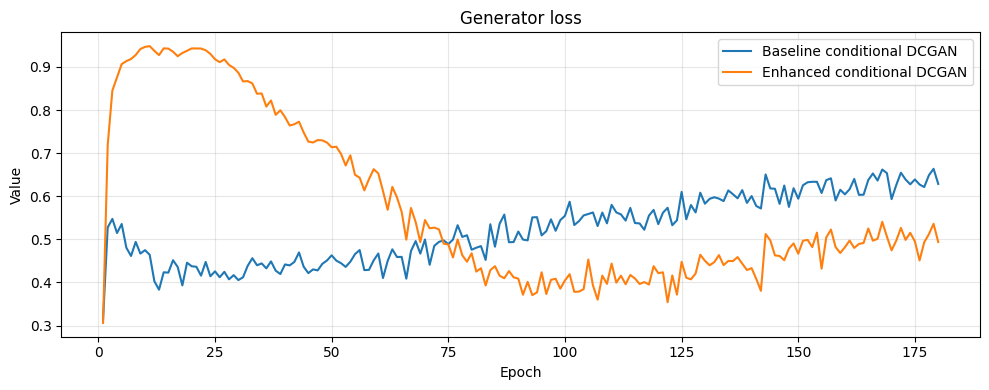

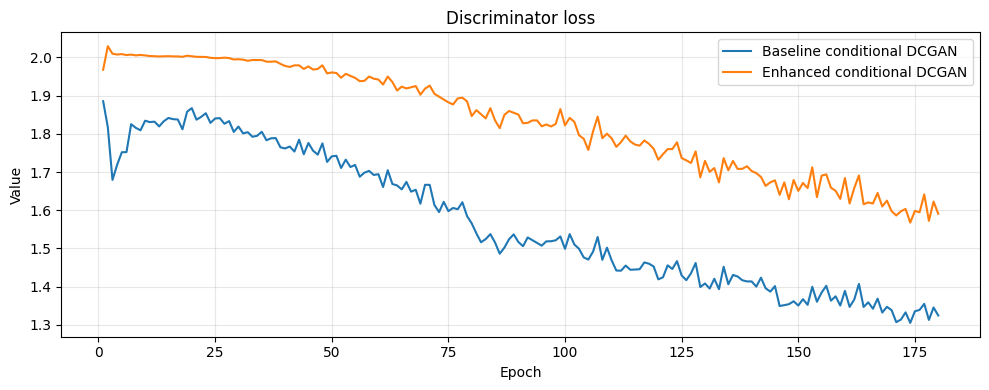

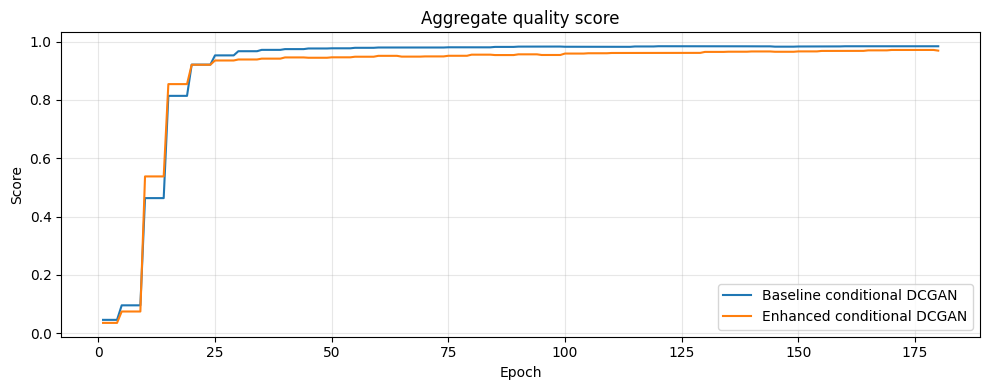

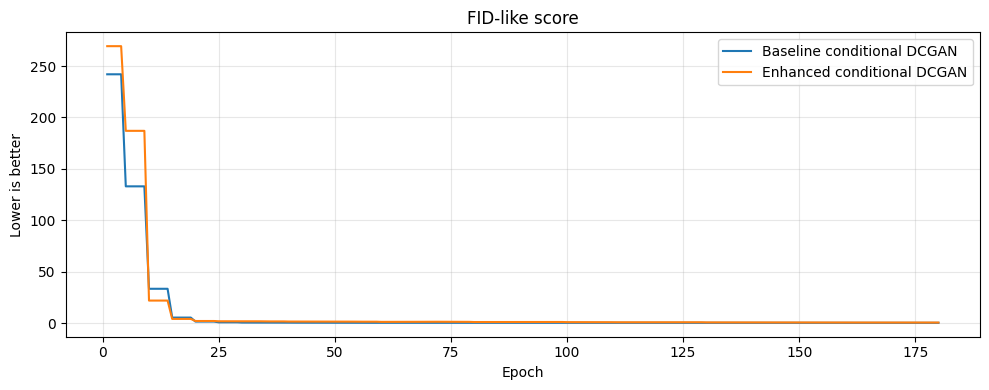

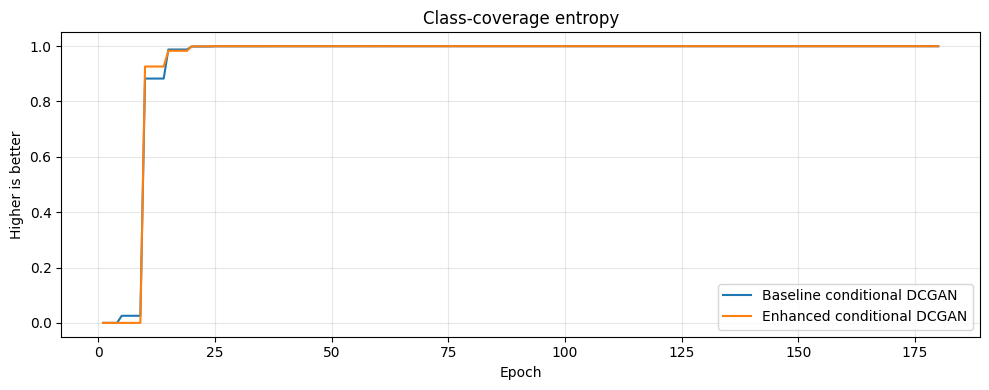

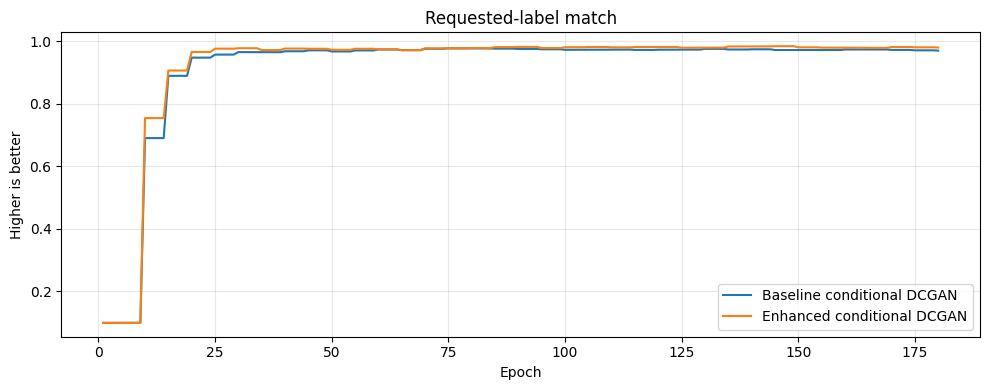

In [25]:
def history_frame(trainer: ConditionalGanTrainer) -> pd.DataFrame:
    """Returns training history as a DataFrame."""
    frame = pd.DataFrame(trainer.history)
    return frame.sort_values("epoch").reset_index(drop=True)


def plot_metric_for_trainers(metric_name: str, title: str, ylabel: str) -> None:
    """Plots one requested metric for all models."""
    plt.figure(figsize=(10, 4))

    for trainer in trainers_by_key.values():
        frame = history_frame(trainer)
        if metric_name not in frame.columns:
            continue
        values = frame[metric_name].ffill()
        plt.plot(frame["epoch"], values, label=trainer.spec.title)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_metric_for_trainers("generator_loss", "Generator loss", "Value")
plot_metric_for_trainers("discriminator_loss", "Discriminator loss", "Value")
plot_metric_for_trainers("quality_score", "Aggregate quality score", "Score")
plot_metric_for_trainers("fid_like", "FID-like score", "Lower is better")
plot_metric_for_trainers("coverage_entropy", "Class-coverage entropy", "Higher is better")
plot_metric_for_trainers("label_match_rate", "Requested-label match", "Higher is better")


**Plot 1. Generator Loss**

The generator-loss curves reflect adversarial competition rather than ordinary supervised convergence, so a lower value is not automatically equivalent to better image quality.

For the baseline model, generator loss starts at `0.3128`, rises to `0.5356` at epoch 5, then settles near `0.40-0.45` during the early and middle stages. In the second half of training it gradually increases, reaching `0.6286` at epoch 180. This rise occurs while the FID-like score remains low and the aggregate quality stays near 0.984, so it indicates a stronger discriminator rather than generator degradation.

The enhanced model follows a different trajectory. Its loss rises sharply from `0.3061` to approximately `0.94` by epochs 10-20, remains high during the early stage, and then gradually falls to the `0.40-0.50` range. The curve shows that the larger generator needs a longer adaptation period before reaching a balanced adversarial regime.

Conclusion: both loss curves are compatible with successful GAN training. The baseline model reaches a useful equilibrium faster, while the enhanced model requires a much longer transition.

**Plot 2. Discriminator Loss**

The baseline discriminator loss begins at `1.8855` and gradually decreases to `1.3246`. The curve is not perfectly monotonic, but the overall trend is clear and stable. This indicates that the discriminator becomes more effective at separating real, generated, and label-mismatched pairs without completely overwhelming the generator.

The enhanced discriminator loss starts at `1.9679`, stays close to `2.0` through much of the early training, and then slowly declines to `1.5908`. The longer high-loss plateau is consistent with the more complex generator and the slower development of a stable adversarial balance.

Neither curve contains an uncontrolled spike, collapse to zero, or non-finite region. The discriminator remains active throughout the run.

Conclusion: the baseline pair establishes a stronger and more efficient equilibrium, while the enhanced pair converges more slowly.

**Plot 3. Aggregate Quality Score**

The aggregate score combines the FID-like distance, class coverage, requested-label agreement, feature diversity, and pixel-artifact penalties.

The baseline score rises from `0.0458` at epoch 1 to `0.4633` at epoch 10, `0.8140` at epoch 15, and `0.9211` at epoch 20. It exceeds `0.96` by epoch 30 and then stabilizes near `0.98`. Its selected checkpoint was epoch 120 with a monitoring score of `0.9841`.

The enhanced model rises from `0.0354` to `0.5376` at epoch 10 and `0.9206` at epoch 20. After that, improvement is slower: the score is `0.9552` at epoch 80, `0.9647` at epoch 130, and `0.9713` at epoch 170.

The curves show that both models learn the conditional task quickly, but the baseline model reaches a higher plateau much earlier.

Conclusion: the baseline generator provides better quality per unit of training time and retains the stronger final aggregate result.

**Plot 4. FID-like Score**

At the beginning of training, the FID-like score is very high: `242.022` for the baseline model and `269.382` for the enhanced model. These values correspond to generated distributions that are still far from real Fashion MNIST features.

The baseline score falls rapidly to `33.360` at epoch 10, `5.336` at epoch 15, `1.471` at epoch 20, and `0.495` at epoch 30. It reaches the `0.18-0.22` range during the later stage.

The enhanced score also improves quickly at first, but then declines more gradually: `21.886` at epoch 10, `4.048` at epoch 15, `2.007` at epoch 20, `1.013` at epoch 80, and `0.469` at epoch 170.

Because the early values are hundreds of times larger than the late values, the standard linear plot compresses the final-stage differences near the horizontal axis. The final evaluation on the restored EMA generators and 6,000 samples gives `0.1614` for the baseline model and `0.4394` for the enhanced model.

Conclusion: both models learn the real feature distribution, but the baseline model reaches it faster and remains substantially closer at the end.

**Plot 5. Class-Coverage Entropy**

Both models begin with entropy near zero because the initial outputs are not distributed across meaningful classes.

By epoch 10, coverage reaches `0.883` for the baseline model and `0.926` for the enhanced model. At epoch 15, the values are `0.988` and `0.983`. From approximately epoch 20 onward, both curves remain effectively at `1.0`.

This confirms that neither model suffers from class-level mode collapse after the initial learning phase. All 10 requested classes remain represented throughout the rest of training.

Conclusion: class coverage is solved early and remains stable for both architectures.

**Plot 6. Requested-Label Match**

Requested-label agreement begins near `0.099`, which is the expected random level for 10 classes.

The baseline model reaches `0.690` at epoch 10, `0.890` at epoch 15, and `0.948` at epoch 20. It then remains mostly in the `0.96-0.98` range.

The enhanced model reaches `0.754` at epoch 10, `0.907` at epoch 15, and `0.966` at epoch 20. During the late stage it generally remains around `0.98`, slightly above the baseline curve.

The enhanced model therefore follows the requested labels somewhat more accurately, especially for difficult upper-body classes. However, this advantage is small compared with the baseline model's stronger FID-like score and much lower computational cost.

**Overall Conclusion from the Training Curves**

The curves describe a stable and successful training run. The baseline model converges faster and achieves the better feature-distribution match. The enhanced model learns class conditioning slightly more accurately, but requires substantially more time and never overtakes the baseline model on aggregate quality.

No curve indicates mode collapse, numerical failure, or a disconnected optimization path.


## 26. Gradient and Speed Diagnostics

This section examines training stability and performance. It shows how many epochs were completed, why training stopped, the shares of existing and finite gradients, and how long each epoch takes.

Gradient norms are displayed as diagnostic plots. With mixed precision, they can look jagged because they are related to loss scaling. This is not an error if the shares of existing and finite gradients remain close to 1 and the losses remain finite.

The primary purpose of the section is to confirm that genuine learning continued throughout the experiment and that no hidden numerical failure occurred.


,model,epochs_completed,stop_reason,min_g_grad_present,min_d_grad_present,min_g_grad_finite,min_d_grad_finite,mean_epoch_time_sec
0,Baseline conditional DCGAN,180,max_epochs,1.0,1.0,0.999621,0.999174,18.462512
1,Enhanced conditional DCGAN,180,max_epochs,1.0,1.0,0.999784,0.999174,31.075644


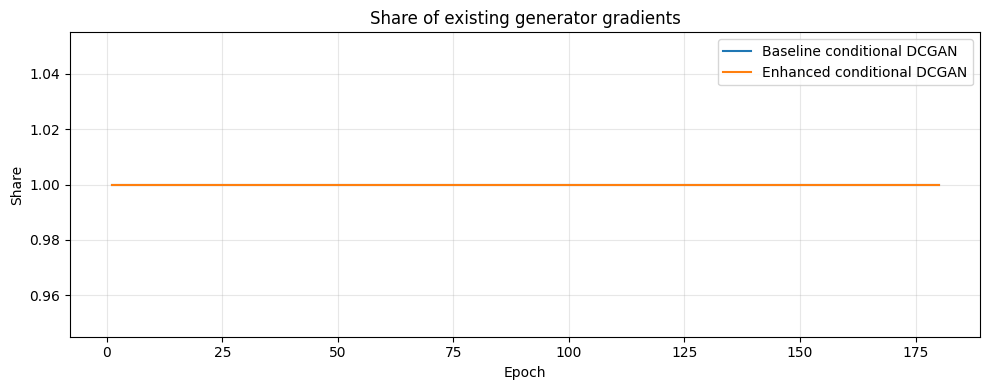

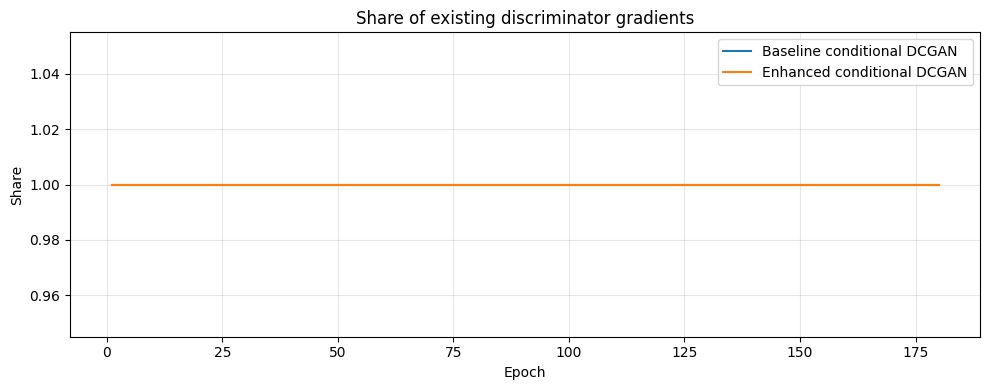

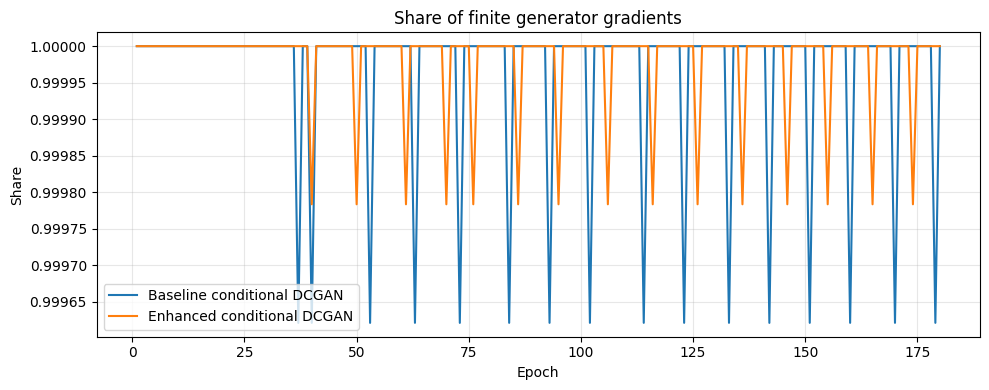

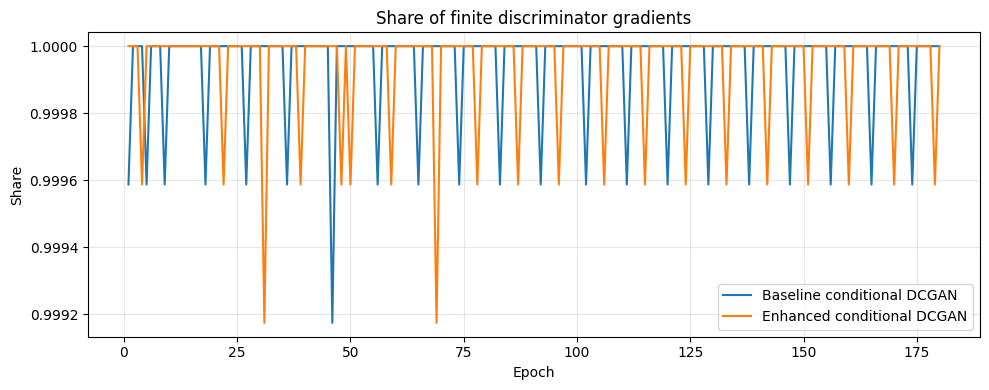

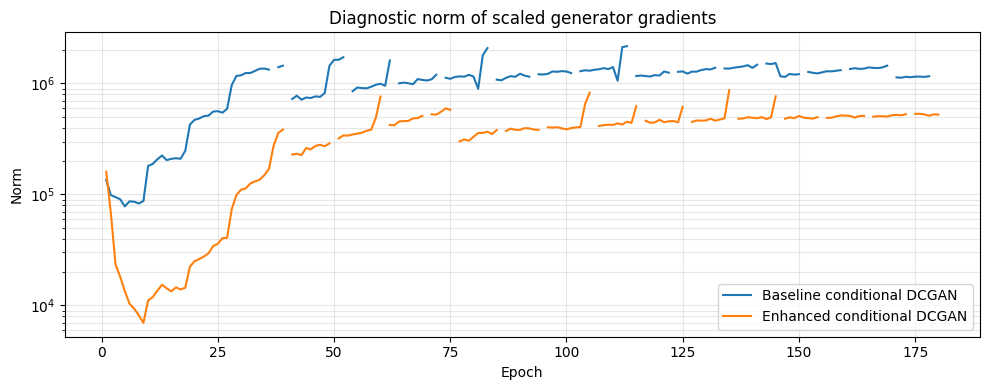

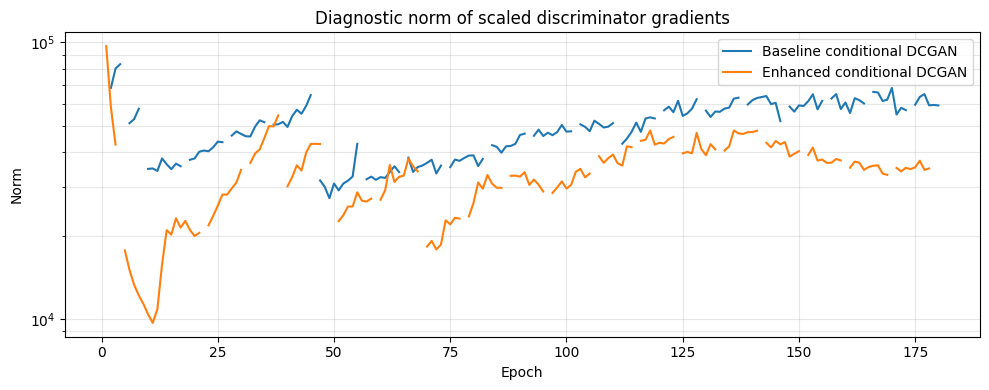

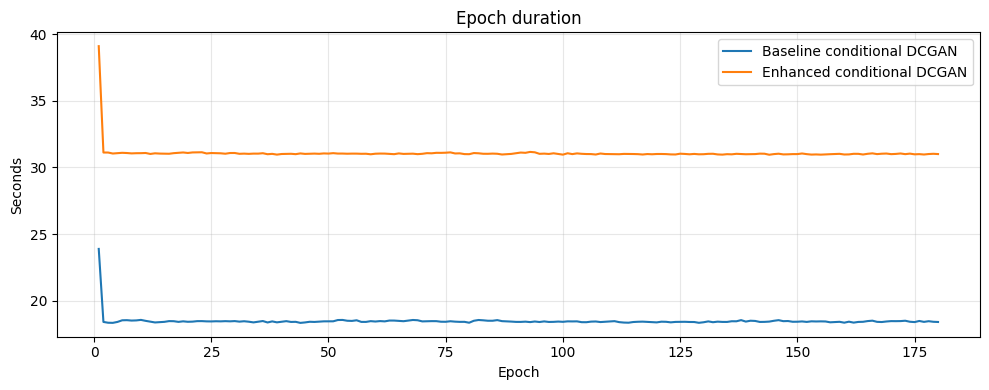

In [26]:
def summarize_training_stability(trainers: Dict[str, ConditionalGanTrainer]) -> pd.DataFrame:
    """Builds a training-stability table for all models."""
    rows = []

    for trainer in trainers.values():
        frame = history_frame(trainer)
        rows.append(
            {
                "model": trainer.spec.title,
                "epochs_completed": int(frame["epoch"].max()),
                "stop_reason": trainer.stop_reason,
                "min_g_grad_present": float(frame["generator_gradient_present_ratio"].min()),
                "min_d_grad_present": float(frame["discriminator_gradient_present_ratio"].min()),
                "min_g_grad_finite": float(frame["generator_gradient_finite_ratio"].min()),
                "min_d_grad_finite": float(frame["discriminator_gradient_finite_ratio"].min()),
                "mean_epoch_time_sec": float(frame["seconds"].mean()),
            }
        )

    return pd.DataFrame(rows)


def safe_history_series(frame: pd.DataFrame, metric_name: str) -> pd.Series:
    """Prepares a metric series for robust plotting."""
    # pd.to_numeric converts accidental string values to numbers and replaces errors with NaN.
    values = pd.to_numeric(frame[metric_name], errors="coerce")

    # Infinite values must not reach the plot because they make the axis scale unreadable.
    values = values.replace([np.inf, -np.inf], np.nan)
    return values


def plot_metric_for_trainers_safe(metric_name: str, title: str, ylabel: str) -> None:
    """Plots a metric with safe handling of missing values."""
    plt.figure(figsize=(10, 4))

    for trainer in trainers_by_key.values():
        frame = history_frame(trainer)
        if metric_name not in frame.columns:
            continue

        # Forward-fill the last value for sparsely evaluated metrics.
        values = safe_history_series(frame, metric_name).ffill()
        plt.plot(frame["epoch"], values, label=trainer.spec.title)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_log_metric_for_trainers(metric_name: str, title: str, ylabel: str) -> None:
    """Plots a positive diagnostic metric on a logarithmic scale."""
    plt.figure(figsize=(10, 4))

    for trainer in trainers_by_key.values():
        frame = history_frame(trainer)
        if metric_name not in frame.columns:
            continue

        values = safe_history_series(frame, metric_name)

        # A logarithmic scale is defined only for positive values.
        values = values.where(values > 0)
        plt.semilogy(frame["epoch"], values, label=trainer.spec.title)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()


stability_table = summarize_training_stability(trainers_by_key)
stability_table.to_csv(TABLE_DIR / "training_stability.csv", index=False)
display(stability_table)

# Main diagnostic: gradients should exist and remain finite in almost every epoch.
plot_metric_for_trainers_safe("generator_gradient_present_ratio", "Share of existing generator gradients", "Share")
plot_metric_for_trainers_safe("discriminator_gradient_present_ratio", "Share of existing discriminator gradients", "Share")
plot_metric_for_trainers_safe("generator_gradient_finite_ratio", "Share of finite generator gradients", "Share")
plot_metric_for_trainers_safe("discriminator_gradient_finite_ratio", "Share of finite discriminator gradients", "Share")

# Gradient norms are retained as an auxiliary diagnostic, not as a generation-quality criterion.
plot_log_metric_for_trainers("generator_gradient_norm", "Diagnostic norm of scaled generator gradients", "Norm")
plot_log_metric_for_trainers("discriminator_gradient_norm", "Diagnostic norm of scaled discriminator gradients", "Norm")
plot_metric_for_trainers_safe("seconds", "Epoch duration", "Seconds")


**Plot 1. Share of Existing Generator Gradients**

Both curves remain exactly at `1.0` for all 180 epochs. Every trainable generator variable receives a gradient in both experiments.

This result confirms that the custom `GradientTape` path is complete and that no generator block is disconnected from the loss.

**Plot 2. Share of Existing Discriminator Gradients**

The discriminator curves also remain at `1.0` throughout training. The convolutional feature extractor, unconditional score, class embedding, and projection term all participate in optimization.

This is particularly important for conditional generation because a disconnected projection branch would allow the discriminator to ignore class labels.

**Plot 3. Share of Finite Generator Gradients**

The minimum recorded finite-gradient share is **0.999621** for the baseline generator and **0.999784** for the enhanced generator.

The graph looks jagged only because the vertical axis is magnified around values extremely close to 1.0. Even the lowest points retain more than 99.96% finite gradient elements. The short drops are compatible with dynamic loss scaling under `mixed_float16` and do not propagate into non-finite losses or weights.

The enhanced generator is marginally better on this diagnostic, but the difference is too small to have practical significance.

**Plot 4. Share of Finite Discriminator Gradients**

Both discriminators have the same minimum recorded finite-gradient share of **0.999174**. This remains above 99.91%, and the curves repeatedly return to 1.0.

The discriminator processes three kinds of pairs - real with correct labels, generated with requested labels, and real with incorrect labels - so slightly sharper gradient behavior is expected. The absence of a sustained decline confirms numerical stability.

**Plot 5. Diagnostic Norm of Scaled Generator Gradients**

The plot shows gradients after mixed-precision loss scaling, so the absolute magnitudes should not be interpreted as ordinary `float32` gradient norms.

The baseline generator generally operates at a higher scaled norm and reaches a stable high range early. The enhanced generator first drops to a lower range, then rises in stages as the architecture adapts. Gaps occur where non-positive or non-finite points are excluded from the logarithmic display.

The relevant conclusion is not that one absolute norm is inherently better, but that both models preserve a non-vanishing learning signal throughout training.

**Plot 6. Diagnostic Norm of Scaled Discriminator Gradients**

Discriminator norms remain within a narrower logarithmic range than generator norms. Both models show transient changes during the initial adaptation phase, followed by a broadly stable operating range.

There is no sustained order-of-magnitude explosion and no collapse toward zero. Together with the finite-gradient shares, this confirms that the discriminator optimization remains controlled.

**Plot 7. Epoch Duration**

The first epoch is slower because TensorFlow traces the compiled functions, initializes GPU kernels, and warms the cached data pipeline. Subsequent epochs are highly stable.

The mean epoch duration is **18.46 seconds** for the baseline model and **31.08 seconds** for the enhanced model. The enhanced architecture is therefore approximately **1.68 times slower per epoch**.

Both models complete all 180 epochs, but the enhanced model's extra computational cost does not produce a better FID-like or aggregate quality score.

**Overall Diagnostic Conclusion**

The diagnostics confirm that:

- all trainable variables receive gradients;
- more than 99.9% of gradient elements remain finite even at the minimum;
- no sustained exploding or vanishing-gradient regime is present;
- the data and computation pipeline produces stable epoch times;
- mixed-precision irregularities remain local and do not damage training.

The training loop is therefore technically sound. The main efficiency conclusion is that the baseline model produces the stronger result with substantially less computation.


## 27. Final Evaluation of the Best EMA Generators

This block evaluates the best EMA generators from both models. The EMA version is used for final results because it smooths weight oscillations and usually produces more stable images.

The final table combines all major metrics. The FID-like score measures proximity of the feature distribution to the real distribution. Class coverage and minimum class share reveal whether any categories are missing. Requested-label agreement measures conditional-generation accuracy.

Pixel-artifact indicators are also included: total variation and the share of strong transitions. This protects the study from a situation in which a model is formally recognized by the classifier but visually produces noise.


In [27]:
def evaluate_final_generators(
    trainers: Dict[str, ConditionalGanTrainer],
    evaluator: QualityEvaluator,
    config: ExperimentConfig,
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, np.ndarray]]]:
    """Computes final metrics and stores detailed data for visualizations."""
    rows = []
    details_by_key = {}

    for key, trainer in trainers.items():
        metrics, details = evaluator.evaluate(
            trainer.ema_generator,
            sample_count=config.final_eval_samples,
            return_details=True,
        )
        row = {"model_key": key, "model": trainer.spec.title, **metrics}
        rows.append(row)
        details_by_key[key] = details

    metrics_frame = pd.DataFrame(rows).sort_values("quality_score", ascending=False).reset_index(drop=True)
    metrics_frame.to_csv(TABLE_DIR / "final_metrics.csv", index=False)
    return metrics_frame, details_by_key


final_metrics, final_details_by_key = evaluate_final_generators(trainers_by_key, quality_evaluator, CONFIG)
display(final_metrics)


,model_key,model,fid_like,coverage_entropy,label_match_rate,min_class_share,missing_class_count,min_condition_match,feature_diversity_ratio,tv_ratio,high_contrast_ratio,mean_confidence,quality_score
0,basic,Baseline conditional DCGAN,0.161411,0.999892,0.972333,0.095333,0.0,0.876667,1.014530,0.961359,0.957870,0.961963,0.984644
1,enhanced,Enhanced conditional DCGAN,0.439422,0.999962,0.982833,0.097833,0.0,0.943333,1.043599,0.916005,0.940426,0.966487,0.972329


The final evaluation uses the restored best EMA generator for each model and a larger sample of 6,000 generated images.

The **Baseline conditional DCGAN** achieved:

- FID-like score: **0.1614**;
- aggregate quality score: **0.9846**;
- class-coverage entropy: **0.9999**;
- requested-label match: **0.9723**;
- minimum class share: **0.0953**;
- minimum per-class condition match: **0.8767**;
- feature-diversity ratio: **1.0145**;
- total-variation ratio: **0.9614**;
- strong-transition ratio: **0.9579**;
- missing classes: **0**.

The **Enhanced conditional DCGAN** achieved:

- FID-like score: **0.4394**;
- aggregate quality score: **0.9723**;
- class-coverage entropy: **1.0000**;
- requested-label match: **0.9828**;
- minimum class share: **0.0978**;
- minimum per-class condition match: **0.9433**;
- feature-diversity ratio: **1.0436**;
- total-variation ratio: **0.9160**;
- strong-transition ratio: **0.9404**;
- missing classes: **0**.

The enhanced model is slightly stronger in label adherence, worst-class performance, and feature diversity. The baseline model is substantially better in FID-like distance, aggregate quality, and resemblance to real pixel-level variation.

Research conclusion: both models solve the conditional generation task, but the baseline model provides the better overall image distribution and the better quality-to-compute ratio.


## 28. Per-Class Quality Table

This block breaks the final evaluation down by each of the 10 Fashion MNIST classes. An aggregate metric can hide weak categories, so conditional generation must also be examined class by class.

The table contains two key quantities: the share of each predicted class among all generated images and the requested-label match within each class. The first measures balance, while the second measures how closely the generator follows the condition.

Particular attention should be paid to upper-body garment classes because they are visually similar and often become the most difficult categories for both the classifier and the generator.


In [28]:
def build_per_class_metrics(details_by_key: Dict[str, Dict[str, np.ndarray]]) -> pd.DataFrame:
    """Builds a per-class quality table."""
    rows = []

    for key, details in details_by_key.items():
        trainer = trainers_by_key[key]
        class_shares = details["class_shares"]
        condition_match = details["condition_match_by_class"]

        for class_id, class_name in enumerate(CLASS_NAMES):
            rows.append(
                {
                    "model_key": key,
                    "model": trainer.spec.title,
                    "class_id": class_id,
                    "class": class_name,
                    "predicted_class_share": float(class_shares[class_id]),
                    "requested_label_match": float(condition_match[class_id]),
                }
            )

    return pd.DataFrame(rows)


per_class_metrics = build_per_class_metrics(final_details_by_key)
per_class_metrics.to_csv(TABLE_DIR / "per_class_metrics.csv", index=False)
display(per_class_metrics)


,model_key,model,class_id,class,predicted_class_share,requested_label_match
0,basic,Baseline conditional DCGAN,0,T-shirt or top,0.099167,0.940000
1,basic,Baseline conditional DCGAN,1,trousers,0.100167,1.000000
2,basic,Baseline conditional DCGAN,2,pullover,0.101000,0.971667
3,basic,Baseline conditional DCGAN,3,dress,0.100500,0.990000
4,basic,Baseline conditional DCGAN,4,coat,0.104500,0.973333
5,basic,Baseline conditional DCGAN,5,sandal,0.099167,0.991667
6,basic,Baseline conditional DCGAN,6,shirt,0.095333,0.876667
7,basic,Baseline conditional DCGAN,7,sneaker,0.101833,0.998333
8,basic,Baseline conditional DCGAN,8,bag,0.099333,0.993333
9,basic,Baseline conditional DCGAN,9,ankle boot,0.099000,0.988333


The per-class table confirms complete class coverage for both generators.

For the baseline model, predicted class shares range from **0.0953** for `shirt` to **0.1045** for `coat`. For the enhanced model, they range from **0.0978** for `T-shirt or top` to **0.1023** for `pullover`. Both ranges are close to the ideal uniform share of 0.10.

The most difficult requested class is `shirt` for both models:

- baseline model: **0.8767** requested-label match;
- enhanced model: **0.9433** requested-label match.

The enhanced architecture therefore improves the separation of the most ambiguous upper-body class by about 6.7 percentage points. It also reaches `0.9917` for `pullover`, compared with `0.9717` for the baseline model.

The most distinctive classes remain very strong. Both models achieve perfect agreement for `trousers`; both reach approximately `0.9983` for `sneaker`, and the enhanced model also reaches `0.9983` for `bag`.

The table explains the trade-off between the models: the enhanced generator follows difficult class labels more reliably, while the baseline generator produces a distribution that is closer to real Fashion MNIST overall.


## 29. Visual Comparison by Class

This block constructs conditional-generation grids. Each row corresponds to one class, while the columns show different examples from that class. This visualization is essential for GAN evaluation because numerical metrics do not fully describe visual quality.

The grid answers several questions: do all classes appear, is the class condition preserved, is there mode collapse, do the images resemble real Fashion MNIST objects, and are excessive noise or barcode-like patterns present?

For the final conclusion, both models should produce recognizable silhouettes in every row rather than performing well for only one or two classes.


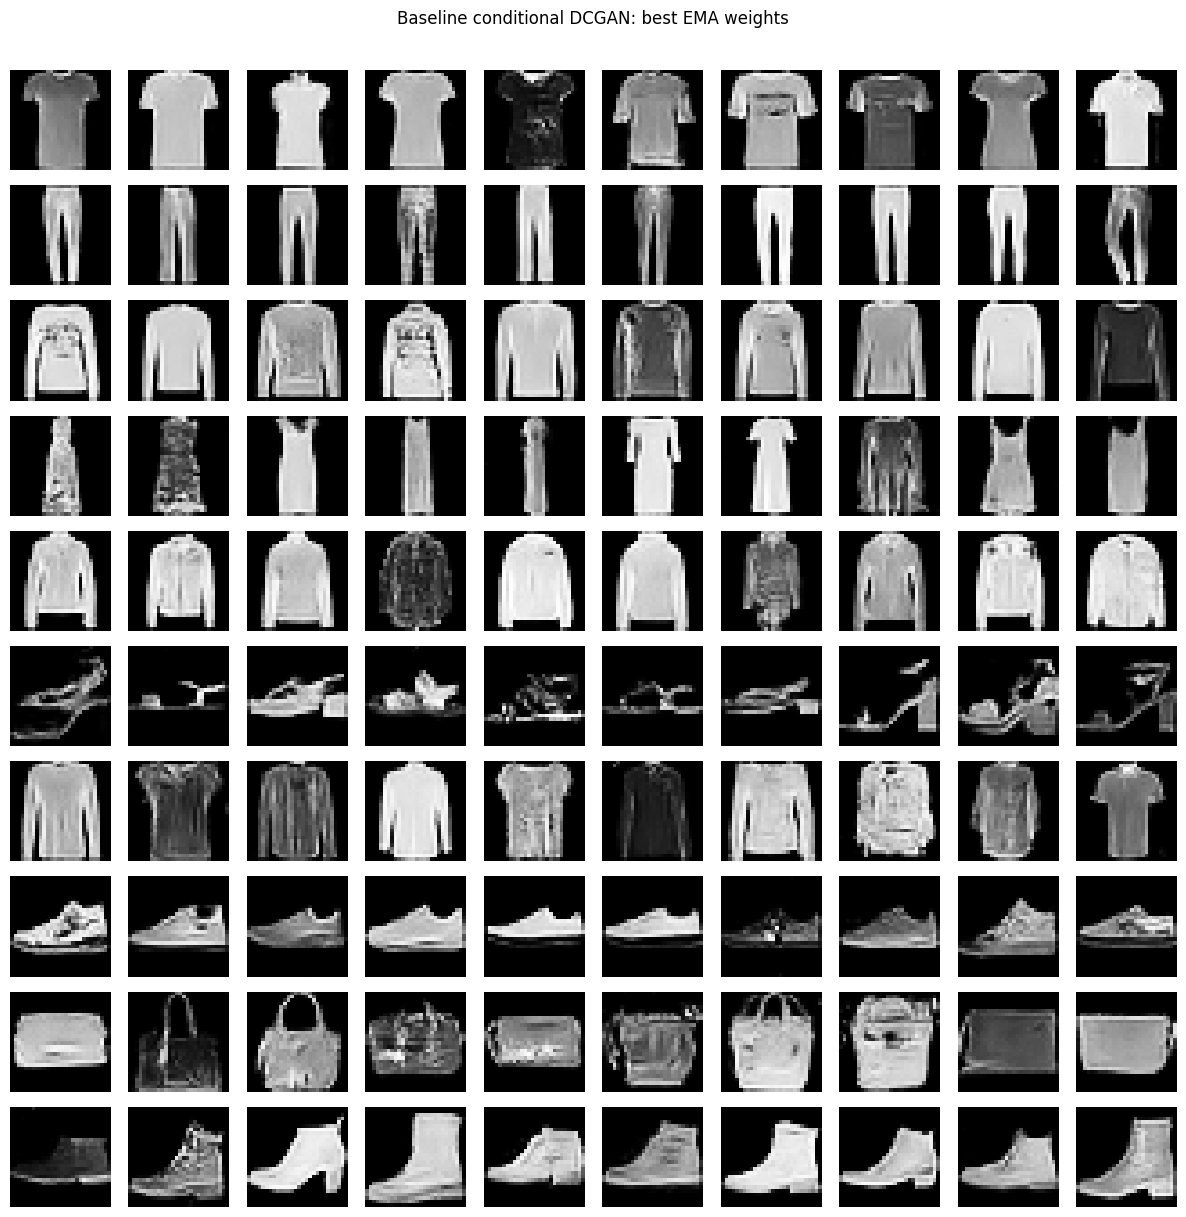

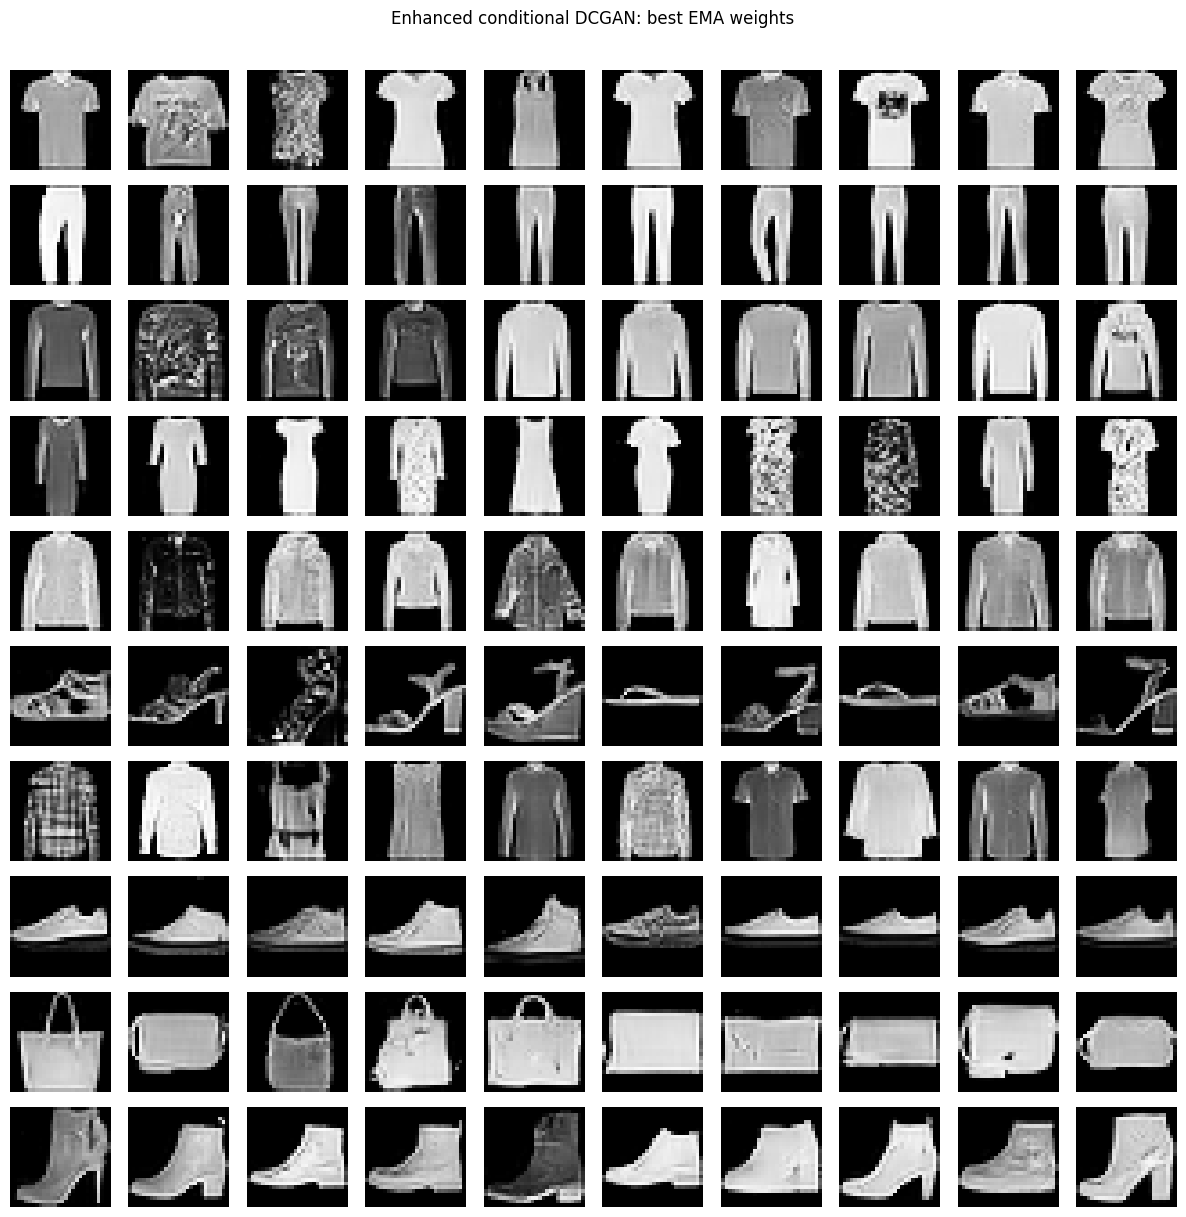

In [29]:
def show_conditioned_grid(
    generator: keras.Model,
    title: str,
    samples_per_class: int,
    config: ExperimentConfig,
    save_path: Optional[Path] = None,
) -> None:
    """Shows a grid of images generated for every class."""
    labels = np.repeat(np.arange(config.num_classes), samples_per_class).astype("int32")
    noise = tf.random.normal([len(labels), config.latent_dim], seed=config.seed)
    images = generator([noise, tf.convert_to_tensor(labels)], training=False).numpy()
    images_01 = gan_to_classifier_range(images)

    fig, axes = plt.subplots(config.num_classes, samples_per_class, figsize=(samples_per_class * 1.2, config.num_classes * 1.2))

    for row, class_name in enumerate(CLASS_NAMES):
        for col in range(samples_per_class):
            image_index = row * samples_per_class + col
            ax = axes[row, col]
            ax.imshow(images_01[image_index, :, :, 0], cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(class_name, rotation=0, labelpad=55, va="center")

    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


for key, trainer in trainers_by_key.items():
    show_conditioned_grid(
        trainer.ema_generator,
        title=f"{trainer.spec.title}: best EMA weights",
        samples_per_class=CONFIG.grid_samples_per_class,
        config=CONFIG,
        save_path=IMAGE_DIR / f"{key}_conditioned_grid.png",
    )


The conditioned image grids agree with the numerical results. Both EMA generators produce recognizable examples for all 10 Fashion MNIST classes, with no missing category and no class-level mode collapse.

The baseline model gives especially consistent silhouettes for `trousers`, footwear, and `bag`. Its upper-body categories remain recognizable, although some `T-shirt or top`, `pullover`, `coat`, and `shirt` samples contain noisy texture or ambiguous local detail. This agrees with the lower per-class match for `shirt`.

The enhanced model shows somewhat stronger separation among the upper-body classes and a higher requested-label match. Its `shirt`, `pullover`, and `T-shirt or top` rows are generally more class-consistent. At the same time, some samples appear slightly smoother or more texture-heavy, which is consistent with its lower total-variation ratio and weaker FID-like score.

Neither grid shows the barcode-like artifacts, complete noise, or repeated single-template collapse observed in unsuccessful earlier experiments. The visual evidence supports the final conclusion: both models are valid, but the enhanced model's improvement in class adherence does not translate into better overall distribution quality.


## 30. Latent-Space Interpolation Across All Classes

Interpolation shows how the generator changes an image as the latent vector varies smoothly. In a good model, changes should be gradual: silhouette, thickness, tilt, or detail should vary smoothly while the class remains stable.

The block performs interpolation for all classes at once. This is a universal check rather than tuning for one category. It helps determine whether the generator has learned a continuous image space or merely produces a collection of disconnected templates.

Abrupt jumps, noise, or disappearing objects during interpolation would indicate problems in the latent space.


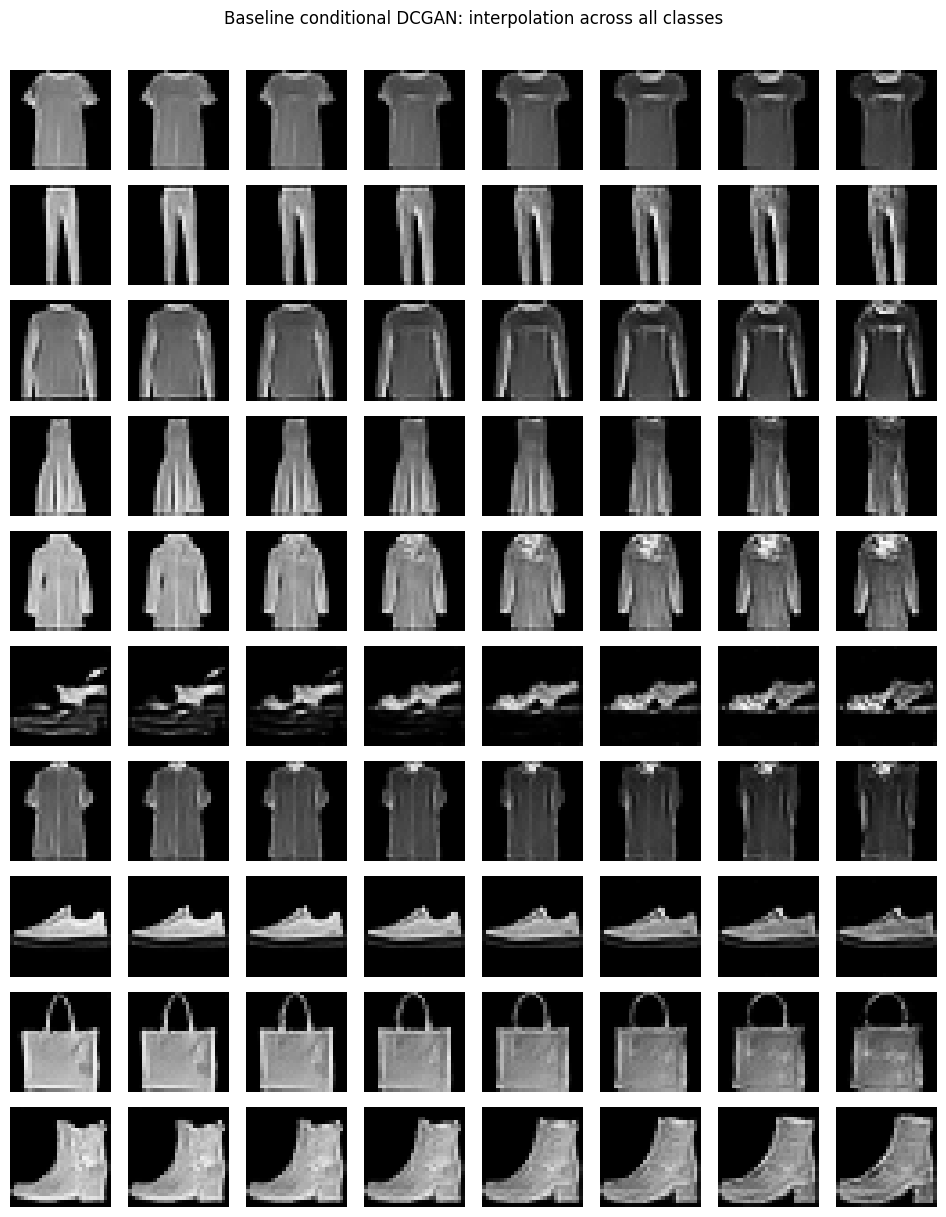

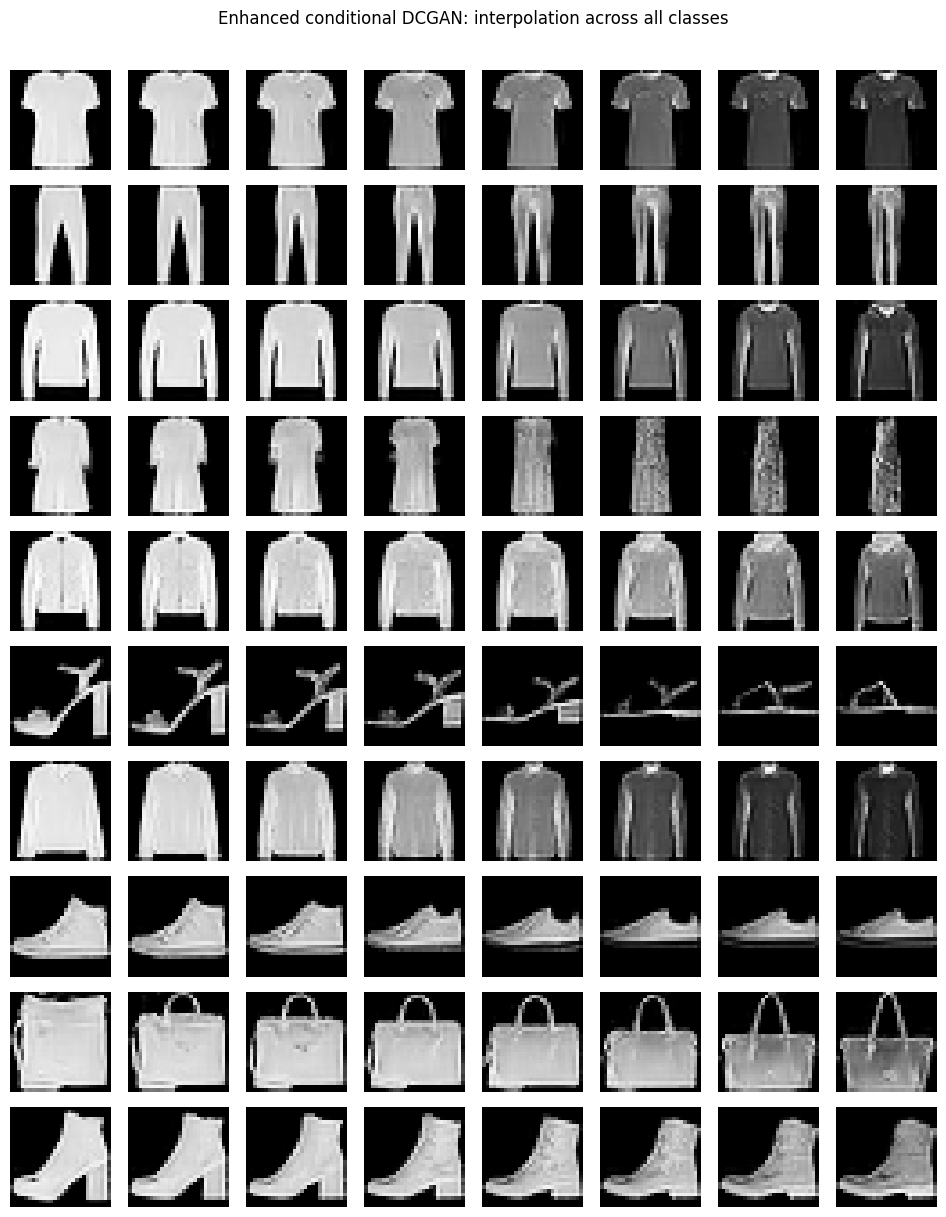

In [30]:
def show_all_class_interpolation(
    generator: keras.Model,
    title: str,
    config: ExperimentConfig,
    interpolation_steps: int = 8,
    save_path: Optional[Path] = None,
) -> None:
    """Shows interpolation between two latent-space points for all classes."""
    start_noise = tf.random.normal([1, config.latent_dim], seed=config.seed + 11)
    end_noise = tf.random.normal([1, config.latent_dim], seed=config.seed + 17)
    weights = tf.linspace(0.0, 1.0, interpolation_steps)[:, None]
    interpolated_noise = (1.0 - weights) * start_noise + weights * end_noise

    fig, axes = plt.subplots(config.num_classes, interpolation_steps, figsize=(interpolation_steps * 1.2, config.num_classes * 1.2))

    for class_id, class_name in enumerate(CLASS_NAMES):
        labels = tf.fill([interpolation_steps], tf.cast(class_id, tf.int32))
        images = generator([interpolated_noise, labels], training=False).numpy()
        images_01 = gan_to_classifier_range(images)

        for col in range(interpolation_steps):
            ax = axes[class_id, col]
            ax.imshow(images_01[col, :, :, 0], cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(class_name, rotation=0, labelpad=55, va="center")

    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


for key, trainer in trainers_by_key.items():
    show_all_class_interpolation(
        trainer.ema_generator,
        title=f"{trainer.spec.title}: interpolation across all classes",
        config=CONFIG,
        interpolation_steps=8,
        save_path=IMAGE_DIR / f"{key}_all_class_interpolation.png",
    )


The interpolation grids show smooth transformations between two latent vectors while the class label remains fixed within each row.

For both models, global attributes such as brightness, width, pose, contour shape, and internal texture change gradually rather than jumping abruptly. This indicates that the generators learned a continuous latent representation instead of a small collection of disconnected templates.

Class identity is preserved especially well for `trousers`, `sneaker`, `bag`, and `ankle boot`. The upper-body rows reveal the expected ambiguity: silhouettes remain within the requested family, but local features can move between patterns associated with T-shirts, pullovers, coats, and shirts.

The enhanced model often preserves the requested category more strongly across the interpolation, which agrees with its higher label-match metrics. The baseline model still produces smooth and coherent paths and remains better on the global FID-like criterion.

The interpolation analysis therefore supports two conclusions: neither model simply memorizes isolated examples, and the conditional variable remains active throughout the latent path.


## 31. Final Comparison Charts

This block converts the final tables into compact bar charts. The plots make it easy to see which model performs better on the key metrics.

When interpreting them, metric direction must be kept in mind. Lower is better for the FID-like score. Higher is better for the aggregate quality score, class coverage, and requested-label agreement.

The plots do not replace the tables or visual inspection. They provide a concise summary of the experimental results.


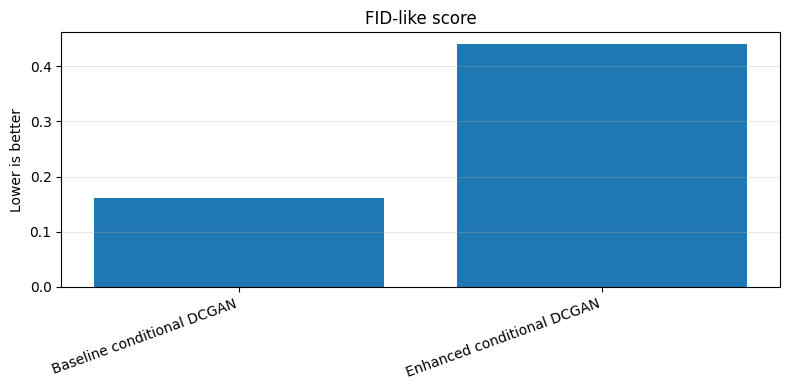

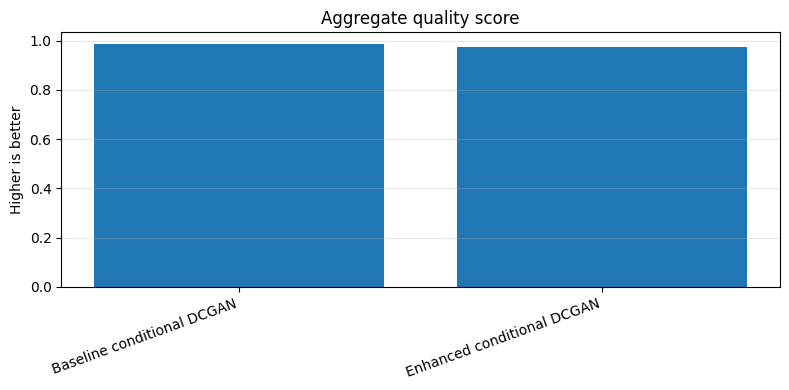

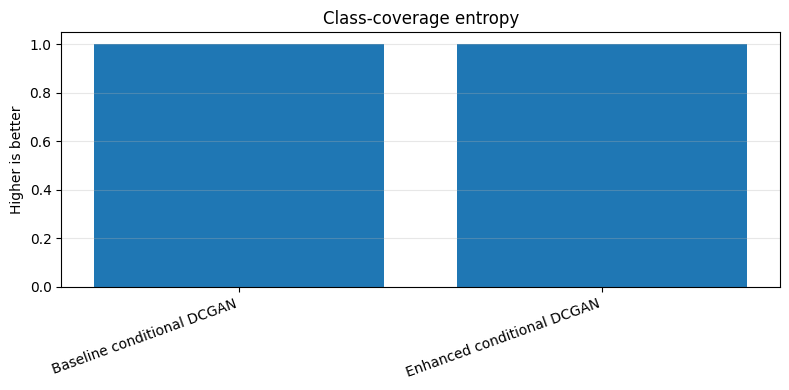

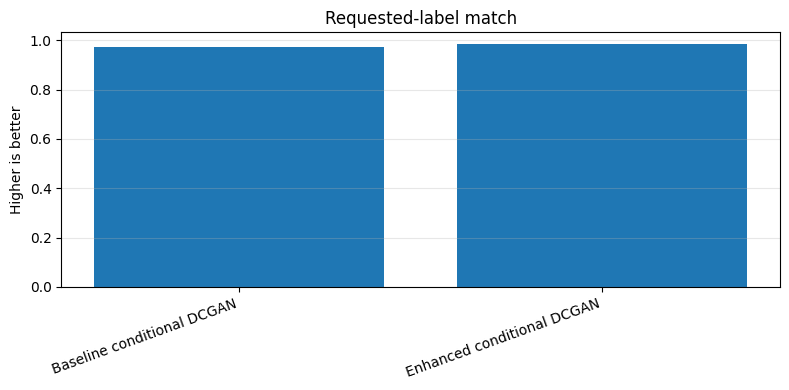

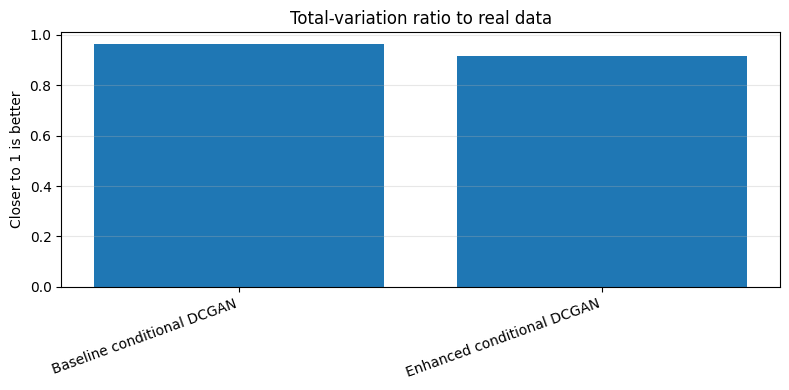

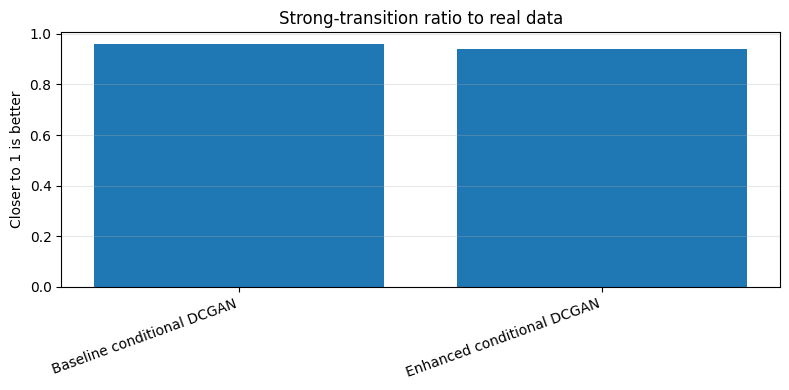

In [31]:
def plot_final_bar(metric_name: str, title: str, ylabel: str) -> None:
    """Plots a bar chart for a final metric."""
    plt.figure(figsize=(8, 4))
    plt.bar(final_metrics["model"], final_metrics[metric_name])
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_final_bar("fid_like", "FID-like score", "Lower is better")
plot_final_bar("quality_score", "Aggregate quality score", "Higher is better")
plot_final_bar("coverage_entropy", "Class-coverage entropy", "Higher is better")
plot_final_bar("label_match_rate", "Requested-label match", "Higher is better")
plot_final_bar("tv_ratio", "Total-variation ratio to real data", "Closer to 1 is better")
plot_final_bar("high_contrast_ratio", "Strong-transition ratio to real data", "Closer to 1 is better")


**Plot 1. FID-like Score**

The baseline model achieves **0.1614**, while the enhanced model achieves **0.4394**. Lower is better, so the baseline model has the clear advantage. Its feature-distribution distance is approximately 63% lower.

This is an adapted FID-like metric computed in the evaluation classifier's feature space, not a standard Inception FID. It is suitable for relative comparison within this Fashion MNIST experiment.

**Plot 2. Aggregate Quality Score**

The baseline model reaches **0.9846**, compared with **0.9723** for the enhanced model. Both values are high, but the baseline model wins because its stronger FID-like result and more realistic pixel-variation ratios outweigh the enhanced model's small advantage in label adherence.

**Plot 3. Class-Coverage Entropy**

The scores are **0.9999** for the baseline model and effectively **1.0000** for the enhanced model. The difference is negligible. Both models distribute generated samples almost uniformly across all 10 classes and have zero missing classes.

**Plot 4. Requested-Label Match**

The enhanced model achieves **0.9828**, compared with **0.9723** for the baseline model. The enhanced architecture is therefore better at following the requested class label, particularly for difficult upper-body garments.

The improvement is real but modest: approximately 1.05 percentage points overall.

**Plot 5. Total-Variation Ratio to Real Data**

The baseline ratio is **0.9614**, while the enhanced ratio is **0.9160**. A value close to 1 is preferable. The baseline outputs therefore reproduce the average amount of local pixel variation in real Fashion MNIST more accurately.

The enhanced value suggests slightly smoother outputs or a loss of some fine local variation.

**Plot 6. Strong-Transition Ratio to Real Data**

The baseline model reaches **0.9579**, and the enhanced model reaches **0.9404**. Both are close to the real-data reference and show no severe high-frequency artifact problem.

The baseline model is again somewhat closer to the real pixel-transition statistics.

**Overall Conclusion from the Final Comparison Charts**

Both models provide high-quality, class-controllable generation with full class coverage. Their strengths differ:

- the baseline model is better in FID-like distance, aggregate quality, total variation, strong-transition similarity, and training speed;
- the enhanced model is better in requested-label agreement, minimum per-class agreement, and feature diversity.

For the primary research goal of generating realistic Fashion MNIST samples efficiently, the baseline conditional DCGAN remains the stronger model.


## 32. Nearest-Neighbor Check

This block compares generated images with their nearest real images from the training set. The goal is to determine whether generation reduces to simply copying training examples.

For each class, the upper row shows generated images and the lower row shows their nearest real neighbors. Labels are placed outside the images so that they do not overlap the content. The distance `d` represents proximity in the feature space of the evaluation classifier.

For Fashion MNIST, small distances are possible even without copying because the images are simple and contain typical silhouettes. The analysis must therefore consider both the numerical distance and the visual similarity of details.


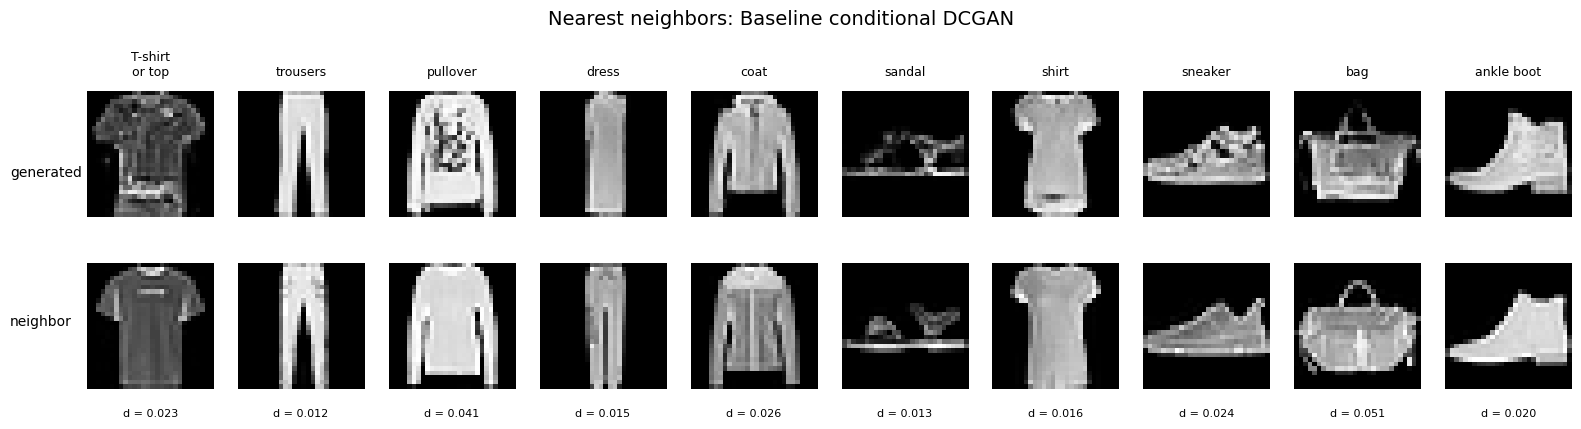

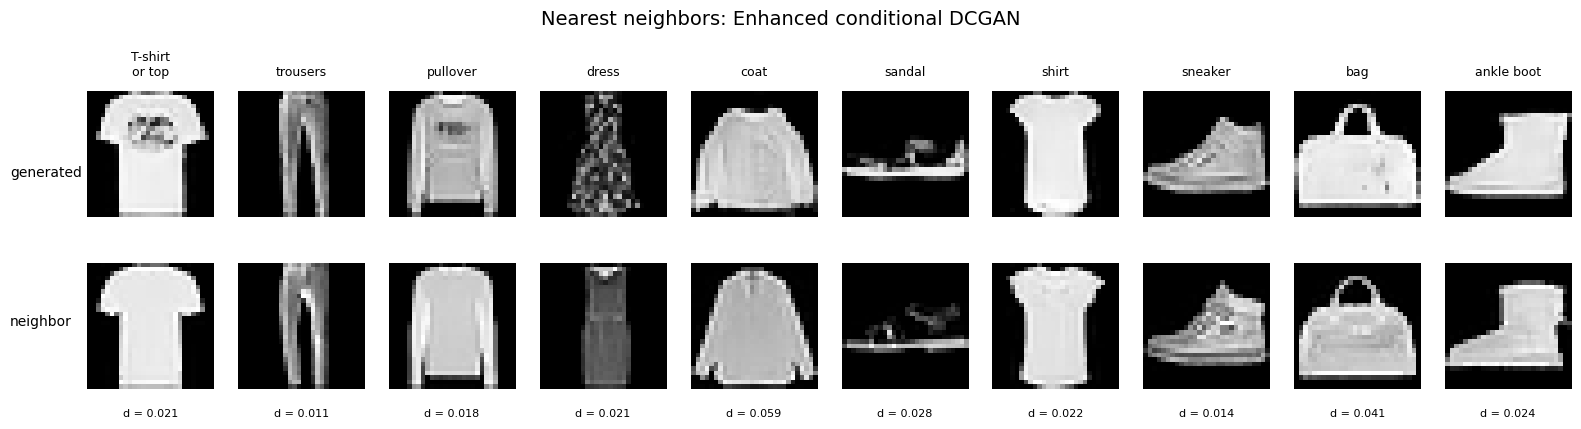

,model,class,nearest_neighbor_index,distance
0,Baseline conditional DCGAN,T-shirt or top,187,0.023038
1,Baseline conditional DCGAN,trousers,1199,0.011516
2,Baseline conditional DCGAN,pullover,1061,0.040735
3,Baseline conditional DCGAN,dress,1000,0.015194
4,Baseline conditional DCGAN,coat,2403,0.025950
5,Baseline conditional DCGAN,sandal,4941,0.012737
6,Baseline conditional DCGAN,shirt,321,0.015628
7,Baseline conditional DCGAN,sneaker,963,0.024475
8,Baseline conditional DCGAN,bag,1662,0.051126
9,Baseline conditional DCGAN,ankle boot,4918,0.019595


In [32]:
def find_nearest_real_indices(
    generated_images_01: np.ndarray,
    real_images_01: np.ndarray,
    max_real_images: int = 5000,
) -> Tuple[np.ndarray, np.ndarray]:
    """Finds the nearest real images for a set of generated images."""
    # Limit the number of real images so the check remains fast in Colab.
    real_subset = real_images_01[:max_real_images]

    # Images are flattened into vectors for nearest-neighbor search.
    generated_flat = generated_images_01.reshape(len(generated_images_01), -1).astype("float32")
    real_flat = real_subset.reshape(len(real_subset), -1).astype("float32")

    nearest_indices = []
    nearest_distances = []
    for generated_vector in generated_flat:
        # Root-mean-square distance is suitable for a coarse memorization check.
        distances = np.mean((real_flat - generated_vector[None, :]) ** 2, axis=1)
        nearest_index = int(np.argmin(distances))
        nearest_indices.append(nearest_index)
        nearest_distances.append(float(distances[nearest_index]))

    return np.array(nearest_indices, dtype="int32"), np.array(nearest_distances, dtype="float32")


def short_class_label(class_name: str) -> str:
    """Returns a compact class label for a narrow plot cell."""
    replacements = {
        "T-shirt or top": "T-shirt\nor top",
    }
    return replacements.get(class_name, class_name)


def show_nearest_neighbors(
    trainer: ConditionalGanTrainer,
    config: ExperimentConfig,
    samples_per_model: Optional[int] = None,
    save_path: Optional[Path] = None,
) -> pd.DataFrame:
    """Shows generated images and their nearest real images without label overlap."""
    # By default, use one example per class so the grid remains readable.
    samples_per_model = samples_per_model or config.num_classes
    if samples_per_model == config.num_classes:
        labels = np.arange(config.num_classes, dtype="int32")
    else:
        labels = build_balanced_labels(samples_per_model, config.num_classes)

    # Generate one fixed set of images for visual inspection.
    noise = tf.random.normal([samples_per_model, config.latent_dim], seed=config.seed + 101)
    generated_images = trainer.ema_generator([noise, tf.convert_to_tensor(labels)], training=False).numpy()
    generated_images_01 = gan_to_classifier_range(generated_images)

    nearest_indices, distances = find_nearest_real_indices(
        generated_images_01,
        train_images_classifier,
        max_real_images=5000,
    )

    # Labels are drawn as separate text elements rather than axis titles.
    # This prevents overlap even when class names are long.
    fig, axes = plt.subplots(
        2,
        samples_per_model,
        figsize=(max(13, samples_per_model * 1.6), 4.8),
    )
    fig.subplots_adjust(left=0.065, right=0.995, top=0.78, bottom=0.16, wspace=0.16, hspace=0.36)
    fig.suptitle(f"Nearest neighbors: {trainer.spec.title}", fontsize=14, y=0.95)
    fig.text(0.018, 0.61, "generated", va="center", ha="left", fontsize=10)
    fig.text(0.018, 0.30, "neighbor", va="center", ha="left", fontsize=10)

    for col in range(samples_per_model):
        generated_axis = axes[0, col]
        nearest_axis = axes[1, col]

        generated_axis.imshow(generated_images_01[col, :, :, 0], cmap="gray", vmin=0, vmax=1)
        generated_axis.axis("off")
        generated_axis.text(
            0.5,
            1.10,
            short_class_label(str(CLASS_NAMES[labels[col]])),
            transform=generated_axis.transAxes,
            ha="center",
            va="bottom",
            fontsize=9,
        )

        nearest_axis.imshow(train_images_classifier[nearest_indices[col], :, :, 0], cmap="gray", vmin=0, vmax=1)
        nearest_axis.axis("off")
        nearest_axis.text(
            0.5,
            -0.16,
            f"d = {distances[col]:.3f}",
            transform=nearest_axis.transAxes,
            ha="center",
            va="top",
            fontsize=8,
        )

    if save_path is not None:
        fig.savefig(save_path, dpi=170, bbox_inches="tight", pad_inches=0.25)
    plt.show()

    # The table supports numerical distance checks without overloading the figure with labels.
    summary = pd.DataFrame(
        {
            "model": trainer.spec.title,
            "class": CLASS_NAMES[labels],
            "nearest_neighbor_index": nearest_indices,
            "distance": distances,
        }
    )
    return summary


nearest_neighbor_tables = []
for key, trainer in trainers_by_key.items():
    nearest_neighbor_tables.append(
        show_nearest_neighbors(
            trainer,
            CONFIG,
            samples_per_model=CONFIG.num_classes,
            save_path=IMAGE_DIR / f"{key}_nearest_neighbors.png",
        )
    )

nearest_neighbors_table = pd.concat(nearest_neighbor_tables, ignore_index=True)
nearest_neighbors_table.to_csv(TABLE_DIR / "nearest_neighbors.csv", index=False)
display(nearest_neighbors_table)


The nearest-neighbor visualization is correctly laid out: class names are placed above the generated row, and feature-space distances are shown below the real-neighbor row without overlapping the images.

For the baseline model, nearest-neighbor distances range from **0.0115** to **0.0511**, with a mean of approximately **0.0240**. For the enhanced model, they range from **0.0108** to **0.0589**, with a mean of approximately **0.0259**.

The smallest distances occur for simple, highly standardized silhouettes such as `trousers`. Larger distances occur for more variable objects such as `bag` and `coat`. This pattern is expected in Fashion MNIST.

The generated and real images share class identity and overall silhouette, but the generated samples are not exact pixel-level duplicates of their nearest training examples. The check therefore finds no visual evidence of direct memorization. The models appear to generate new combinations within the learned class distributions.


## 33. Automated Research Summary

This block produces a textual summary from the final metrics. It selects the best model according to several criteria and checks for risks: missing classes, weak coverage, poor requested-label agreement, and excessive pixel artifacts.

The automated summary helps record the result of a run, but the final research conclusion must also consider the training curves, visual grids, per-class table, and nearest-neighbor analysis.

If the automated summary contains no warnings, the model has passed the main numerical checks, but visual evaluation remains an essential part of GAN analysis.


In [33]:
def format_model_metric(frame: pd.DataFrame, metric: str, better: str) -> str:
    """Returns a string describing the best model for a metric."""
    if better == "min":
        row = frame.loc[frame[metric].idxmin()]
    else:
        row = frame.loc[frame[metric].idxmax()]
    return f"{row['model']} ({metric} = {row[metric]:.4f})"


def print_final_conclusion(metrics_frame: pd.DataFrame) -> None:
    """Prints a concise summary of the model comparison."""
    print("Final comparison")
    print("-" * 80)
    print("Best model by FID-like score:", format_model_metric(metrics_frame, "fid_like", "min"))
    print("Best model by aggregate quality score:", format_model_metric(metrics_frame, "quality_score", "max"))
    print("Best model by requested-label match:", format_model_metric(metrics_frame, "label_match_rate", "max"))
    print("Best model by class coverage:", format_model_metric(metrics_frame, "coverage_entropy", "max"))

    print("\nRisk check")
    for _, row in metrics_frame.iterrows():
        warnings_list = []
        if row["missing_class_count"] > 0:
            warnings_list.append(f"missing classes: {int(row['missing_class_count'])}")
        if row["label_match_rate"] < 0.70:
            warnings_list.append("weak requested-label agreement")
        if row["fid_like"] > 15:
            warnings_list.append("high FID-like score")
        if row["tv_ratio"] > 1.8 or row["high_contrast_ratio"] > 2.0:
            warnings_list.append("possible noisy or barcode-like artifacts")

        status = "no substantial warnings" if not warnings_list else "; ".join(warnings_list)
        print(f"{row['model']}: {status}")


print_final_conclusion(final_metrics)


Final comparison
--------------------------------------------------------------------------------
Best model by FID-like score: Baseline conditional DCGAN (fid_like = 0.1614)
Best model by aggregate quality score: Baseline conditional DCGAN (quality_score = 0.9846)
Best model by requested-label match: Enhanced conditional DCGAN (label_match_rate = 0.9828)
Best model by class coverage: Enhanced conditional DCGAN (coverage_entropy = 1.0000)

Risk check
Baseline conditional DCGAN: no substantial warnings
Enhanced conditional DCGAN: no substantial warnings


The automated summary is consistent with the detailed evaluation.

The **Baseline conditional DCGAN** is selected as the best model by:

- FID-like score: **0.1614**;
- aggregate quality score: **0.9846**.

The **Enhanced conditional DCGAN** is selected as the best model by:

- requested-label match: **0.9828**;
- class-coverage entropy: approximately **1.0000**.

The risk check reports no substantial warning for either model. Both have zero missing classes, nearly uniform class shares, controlled pixel-transition ratios, and strong requested-label agreement.

The summary should be read together with the visual grids and nearest-neighbor check. All three evidence sources agree that both models trained successfully, while the baseline model offers the better overall realism and efficiency.


## 34. Extended Research Analysis of the Completed Run

The completed NVIDIA L4 run produced stable training and strong conditional generation for both DCGAN architectures. The experiment passed every planned validation stage: data analysis, independent classifier training, one-step optimizer validation, full GAN training, gradient diagnostics, EMA checkpoint restoration, final quantitative evaluation, class-wise analysis, visual inspection, latent interpolation, and nearest-neighbor comparison.

### Data and Experimental Conditions

Fashion MNIST is balanced by construction: each class has 6,000 training examples and 1,000 test examples. The images are centered, single-channel, and dominated by a dark background. This makes silhouette information particularly important.

Because all classes are equally represented, any missing generated category would indicate a modeling or optimization problem rather than source-data imbalance. In this run, both generators ultimately cover all 10 classes almost uniformly.

The L4 profile used a batch size of 512, 220 steps per epoch, 180 GAN epochs, a latent dimension of 128, and mixed-precision computation.

### Independent Evaluation Classifier

The classifier achieved a best validation accuracy of **0.9317** at epoch 25, with validation loss **0.1989**. The final training accuracy was **0.9431**, leaving only a small generalization gap.

The learning-rate schedule reduced the rate twice, from `1e-3` to `5e-4` and then to `2.5e-4`. These reductions helped the model move from a validation plateau to the final best result.

The classifier is used only for evaluation and feature extraction. It does not provide a training loss to the generators, which reduces the risk that a generator learns classifier-specific adversarial patterns.

### Real-Data Reference Statistics

The reference statistics are:

- mean total variation: **0.1560**;
- strong-transition share: **0.0359**;
- mean feature standard deviation: **0.7074**.

These values support the final artifact and diversity diagnostics.

### Validation of the Custom Training Loop

The one-step smoke test confirmed real parameter updates for all four model components. Generator-weight changes were approximately `0.000197`, and discriminator-weight changes were approximately `0.000200`.

This check is important because a custom mixed-precision GAN loop can appear to run even when gradients are disconnected or scaled incorrectly. That failure mode is absent here.

### Training Dynamics

The baseline model improves very rapidly. Its FID-like score falls from **242.022** at epoch 1 to **33.360** at epoch 10, **5.336** at epoch 15, **1.471** at epoch 20, and **0.495** at epoch 30. Its aggregate score exceeds 0.96 by epoch 30.

The enhanced model also learns the conditional structure early, but its distributional improvement is slower. Its FID-like score falls from **269.382** at epoch 1 to **21.886** at epoch 10, **2.007** at epoch 20, **1.013** at epoch 80, and **0.469** at epoch 170.

The selected EMA checkpoints are epoch **120** for the baseline model and epoch **170** for the enhanced model. Both runs complete all 180 epochs without a numerical stop.

The mean epoch duration is **18.46 seconds** for the baseline model and **31.08 seconds** for the enhanced model. The enhanced architecture is approximately 1.68 times slower.

### Numerical Stability

Every trainable variable receives a gradient throughout training. The minimum finite-gradient shares remain above 99.9%:

- baseline generator: **0.999621**;
- enhanced generator: **0.999784**;
- both discriminators: **0.999174**.

The small visible drops are local mixed-precision effects rather than sustained instability. No non-finite loss or damaged checkpoint appears.

### Final Quantitative Results

The restored baseline EMA generator achieves:

- FID-like score: **0.1614**;
- aggregate quality: **0.9846**;
- label match: **0.9723**;
- class coverage: **0.9999**;
- feature-diversity ratio: **1.0145**;
- total-variation ratio: **0.9614**;
- strong-transition ratio: **0.9579**.

The restored enhanced EMA generator achieves:

- FID-like score: **0.4394**;
- aggregate quality: **0.9723**;
- label match: **0.9828**;
- class coverage: approximately **1.0000**;
- feature-diversity ratio: **1.0436**;
- total-variation ratio: **0.9160**;
- strong-transition ratio: **0.9404**.

Both models have zero missing classes.

### Per-Class Findings

The class shares remain close to the ideal 0.10 for both generators. The baseline range is **0.0953-0.1045**, and the enhanced range is **0.0978-0.1023**.

`Shirt` is the hardest requested class. The baseline model reaches **0.8767**, while the enhanced model reaches **0.9433**. This is the clearest substantive advantage of the enhanced generator. It distinguishes visually similar upper-body garments more effectively.

Distinctive classes such as `trousers`, `sneaker`, `bag`, and `ankle boot` achieve very high requested-label agreement.

### Visual Evaluation

The image grids confirm that both models produce recognizable examples from all 10 classes. The baseline model has strong silhouettes and realistic local variation, while the enhanced model provides somewhat better class consistency among upper-body garments.

The enhanced outputs can appear slightly smoother, which agrees with the lower total-variation ratio. No complete noise, barcode artifact, or single-template collapse is present.

### Latent-Space Interpolation

Both interpolation grids show smooth within-class transformations. Shape, brightness, width, pose, and texture change gradually. The class identity is generally preserved across each row.

This supports the interpretation that the models learned continuous latent manifolds rather than only storing isolated templates.

### Nearest-Neighbor Analysis

Baseline nearest-neighbor distances range from **0.0115** to **0.0511**, with mean **0.0240**. Enhanced distances range from **0.0108** to **0.0589**, with mean **0.0259**.

Generated samples resemble real examples in class and silhouette but are not exact duplicates. There is no visual evidence of direct training-set copying.

### Final Research Conclusion

Both architectures solve the conditional Fashion MNIST generation task successfully.

The enhanced generator's main advantage is stronger requested-label adherence, especially for the difficult `shirt` class. However, it is approximately 1.68 times slower per epoch and performs worse on the FID-like and aggregate quality criteria.

The baseline conditional DCGAN therefore provides the best balance of realism, class coverage, stability, and computational efficiency for 28 x 28 Fashion MNIST images.


## 35. Saving Results

The final block saves the experiment artifacts: metric tables, training history, best-model weights, images, and the textual summary.

Saving is required for reproducibility and later analysis. The tables can be used in a report, the images for visual comparison, and the weights for repeated generation without retraining.

The artifact directory is printed in the cell output. In Colab, these files can be downloaded or saved to Google Drive if needed.


In [34]:
def save_experiment_artifacts(
    trainers: Dict[str, ConditionalGanTrainer],
    final_metrics_frame: pd.DataFrame,
    per_class_frame: pd.DataFrame,
    config: ExperimentConfig,
) -> None:
    """Saves the key project artifacts."""
    with open(PROJECT_DIR / "config.json", "w", encoding="utf-8") as file:
        json.dump(asdict(config), file, ensure_ascii=False, indent=2)

    final_metrics_frame.to_csv(TABLE_DIR / "final_metrics.csv", index=False)
    per_class_frame.to_csv(TABLE_DIR / "per_class_metrics.csv", index=False)
    stability_table.to_csv(TABLE_DIR / "training_stability.csv", index=False)

    for key, trainer in trainers.items():
        trainer.generator.save_weights(MODEL_DIR / f"{key}_generator_final.weights.h5")
        trainer.ema_generator.save_weights(MODEL_DIR / f"{key}_ema_generator_final.weights.h5")
        trainer.discriminator.save_weights(MODEL_DIR / f"{key}_discriminator_final.weights.h5")

    print(f"Artifacts saved to: {PROJECT_DIR}")


save_experiment_artifacts(trainers_by_key, final_metrics, per_class_metrics, CONFIG)


Artifacts saved to: /content/dcgan_fashion_mnist_final
